# 🔒 Network-Based Intrusion Detection for Smart Grid Systems
## A Machine Learning Approach Using the Sherlock Dataset

---

### 📋 Project Overview

**Objective:** Develop a machine learning-based intrusion detection system (IDS) for smart grid networks using network traffic features extracted from PCAP files.

**Dataset:** Sherlock Dataset for Cyber-Physical Intrusion Detection in Smart Grids

**Approach:** Train models on Basic and Semiurban scenarios, evaluate cross-scenario transferability on Rural (unseen) topology.

**Key Research Question:** Can network traffic patterns alone detect cyber-physical attacks on smart grid systems?

---

### 🎯 Research Contributions

1. **Network-Only Detection:** Evaluate effectiveness of PCAP-derived features without SCADA process data
2. **Cross-Scenario Transferability:** Test model generalization across different grid topologies
3. **Baseline Benchmarks:** Establish performance baselines for future hybrid (network + process) models

---

### 📊 Dataset Scenarios

| Scenario | Training | Testing | Grid Type |
|----------|----------|---------|-----------|
| **Basic** | ✅ | ✅ | Small residential grid |
| **Semiurban** | ✅ | ✅ | Medium mixed-use grid |
| **Rural** | ❌ | ✅ | Large rural grid (transfer test) |

---

## 📦 Section 1: Environment Setup & Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Progress tracking
from tqdm import tqdm

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully")
print(f"   Pandas: {pd.__version__}")
print(f"   NumPy: {np.__version__}")
print(f"   Scikit-learn imported")
print(f"   XGBoost: {xgb.__version__}")

✅ All libraries imported successfully
   Pandas: 2.2.2
   NumPy: 2.0.2
   Scikit-learn imported
   XGBoost: 3.1.0


---

## 🗂️ Section 2: Dataset Description

### Network Feature Explanation

The dataset contains **per-second aggregated network traffic features** extracted from PCAP files:

#### 📊 Traffic Volume Features
- **`bytes`** - Total bytes transmitted per second
- **`packets`** - Total packet count per second
- **`bytes_per_packet`** - Average packet size
- **`packets_per_sec`** - Packet rate (should equal `packets` for 1-sec windows)

#### 🔀 Protocol Behavior Features
- **`syn_ratio`** - Ratio of SYN flags (connection initiation)
- **`ack_ratio`** - Ratio of ACK flags (acknowledgments)
- **`psh_ratio`** - Ratio of PSH flags (push data)

#### 🌐 Diversity & Entropy Features
- **`unique_src_ips`** - Number of unique source IP addresses
- **`unique_dst_ips`** - Number of unique destination IP addresses
- **`unique_dst_ports`** - Number of unique destination ports
- **`src_ip_entropy`** - Shannon entropy of source IP distribution
- **`dst_ip_entropy`** - Shannon entropy of destination IP distribution
- **`dst_port_entropy`** - Shannon entropy of destination port distribution

#### 📏 Statistical Features
- **`packet_size_mean`** - Mean packet size
- **`packet_size_std`** - Standard deviation of packet sizes

---

### Why These Features Matter for Attack Detection

| Feature Type | Relevance to Attacks |
|--------------|---------------------|
| **Volume** | DDoS attacks → traffic spikes; stealthy attacks → minimal changes |
| **Protocol Ratios** | SYN floods → high SYN ratio; reconnaissance → unusual flag patterns |
| **Diversity** | Scanning → many unique IPs/ports; targeted attacks → few IPs |
| **Entropy** | Normal traffic → low entropy; attacks → high randomness or very low (repetitive) |

---

## 📂 Section 3: Data Loading

In [2]:
# Define file paths
DATA_DIR = Path(".")  # Assuming CSVs are in current directory

# Network CSV files
NETWORK_FILES = {
    'basic_train': '/kaggle/input/datasets/ayuusss/pcsp-csvs/network_csvs/basic_train_labeled.csv',
    'basic_test': '/kaggle/input/datasets/ayuusss/pcsp-csvs/network_csvs/basic_test_labeled.csv',
    'semi_train': '/kaggle/input/datasets/ayuusss/pcsp-csvs/network_csvs/semi_train_labeled.csv',
    'semi_test': '/kaggle/input/datasets/ayuusss/pcsp-csvs/network_csvs/semi_test_labeled.csv',
    'rural_test': '/kaggle/input/datasets/ayuusss/pcsp-csvs/network_csvs/rural_test_labeled.csv'
}

# Attack event files (JSONL format)
EVENT_FILES = {
    'basic_train': '/kaggle/input/datasets/ayuusss/sherlock/01-Basic/01-Basic/raw/train/events.jsonl',
    'basic_test': '/kaggle/input/datasets/ayuusss/sherlock/01-Basic/01-Basic/raw/test/events.jsonl',
    'semi_train': '/kaggle/input/datasets/ayuusss/sherlock/02-Semiurban/02-Semiurban/raw/train/events.jsonl',
    'semi_test': '/kaggle/input/datasets/ayuusss/sherlock/02-Semiurban/02-Semiurban/raw/test/events.jsonl',
    'rural_test': '/kaggle/input/datasets/ayuusss/sherlock/03-Rural/03-Rural/raw/test/events.jsonl'
}

print("📁 File paths configured")
print(f"   Network files: {len(NETWORK_FILES)}")
print(f"   Event files: {len(EVENT_FILES)}")

📁 File paths configured
   Network files: 5
   Event files: 5


In [3]:
!apt-get update
!apt-get install -y tshark

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,473 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,947 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]
Get:13 http://security.ubuntu.com/ubuntu jamm

In [4]:
def load_network_data(filepath):
    """
    Load network traffic CSV file.
    
    Args:
        filepath: Path to CSV file
        
    Returns:
        DataFrame with network features
    """
    try:
        df = pd.read_csv(filepath)
        print(f"✅ Loaded {filepath}")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {list(df.columns)}")
        return df
    except FileNotFoundError:
        print(f"❌ File not found: {filepath}")
        return pd.DataFrame()

# Load all network data
network_data = {}

for name, filepath in NETWORK_FILES.items():
    print(f"\n📊 Loading {name}...")
    network_data[name] = load_network_data(filepath)

print(f"\n✅ Loaded {len([d for d in network_data.values() if not d.empty])}/{len(NETWORK_FILES)} datasets")


📊 Loading basic_train...
✅ Loaded /kaggle/input/datasets/ayuusss/pcsp-csvs/network_csvs/basic_train_labeled.csv
   Shape: (39331, 24)
   Columns: ['ts', 'bytes', 'packets', 'packets_per_sec', 'packet_size_mean', 'packet_size_std', 'packet_size_min', 'packet_size_max', 'syn_ratio', 'ack_ratio', 'fin_ratio', 'rst_ratio', 'psh_ratio', 'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports', 'src_ip_entropy', 'dst_ip_entropy', 'dst_port_entropy', 'tcp_ratio', 'udp_ratio', 'icmp_ratio', 'label', 'attack_type']

📊 Loading basic_test...
✅ Loaded /kaggle/input/datasets/ayuusss/pcsp-csvs/network_csvs/basic_test_labeled.csv
   Shape: (42196, 25)
   Columns: ['ts', 'bytes', 'packets', 'packets_per_sec', 'packet_size_mean', 'packet_size_std', 'packet_size_min', 'packet_size_max', 'syn_ratio', 'ack_ratio', 'fin_ratio', 'rst_ratio', 'psh_ratio', 'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports', 'src_ip_entropy', 'dst_ip_entropy', 'dst_port_entropy', 'tcp_ratio', 'udp_ratio', 'icmp_ratio', 'lab

---

## 🏷️ Section 4: Attack Label Generation

### Challenge
Attack annotations are provided as **time intervals** in JSONL format, but our network data is **per-second samples**.

### Solution
Convert attack intervals into binary labels for each second:
- **0** = Benign (normal operation)
- **1** = Attack (malicious activity)

### Approach
1. Parse JSONL events
2. Filter out benign events (e.g., "Cable Maintenance")
3. For each second in network data, check if it falls within any attack interval
4. Assign label accordingly

---

In [5]:
"""
Simple Event File Inspector
Just run this to see what's inside your events.jsonl files
"""

import json
from pathlib import Path

print("="*70)
print("EVENT FILE INSPECTOR")
print("="*70)

# List of event files to check
event_files = [
     '/kaggle/input/datasets/ayuusss/sherlock/01-Basic/01-Basic/raw/train/events.jsonl',
     '/kaggle/input/datasets/ayuusss/sherlock/01-Basic/01-Basic/raw/test/events.jsonl',
     '/kaggle/input/datasets/ayuusss/sherlock/02-Semiurban/02-Semiurban/raw/train/events.jsonl',
     '/kaggle/input/datasets/ayuusss/sherlock/02-Semiurban/02-Semiurban/raw/test/events.jsonl',
     '/kaggle/input/datasets/ayuusss/sherlock/03-Rural/03-Rural/raw/test/events.jsonl'
]

for filename in event_files:
    print(f"\n{'='*70}")
    print(f"📄 FILE: {filename}")
    print(f"{'='*70}")
    
    # Check if file exists
    if not Path(filename).exists():
        print(f"❌ File not found: {filename}")
        continue
    
    # Try to read the file
    try:
        events = []
        
        # Try JSONL format (one JSON per line)
        with open(filename, 'r') as f:
            for line_num, line in enumerate(f, 1):
                if line.strip():
                    try:
                        event = json.loads(line)
                        events.append(event)
                    except json.JSONDecodeError as e:
                        print(f"   ⚠️  Line {line_num} parse error: {e}")
                        print(f"   Content: {line[:100]}")
        
        # If no events loaded, try regular JSON
        if not events:
            with open(filename, 'r') as f:
                data = json.load(f)
                events = data if isinstance(data, list) else [data]
        
        print(f"\n✅ Loaded successfully!")
        print(f"   Total events: {len(events)}")
        
        if events:
            # Show first event in detail
            print(f"\n📊 FIRST EVENT STRUCTURE:")
            print(f"   Keys: {list(events[0].keys())}")
            print(f"\n   Full first event:")
            print(json.dumps(events[0], indent=2))
            
            # Show all unique keys across all events
            all_keys = set()
            for event in events:
                all_keys.update(event.keys())
            print(f"\n📋 ALL UNIQUE KEYS ACROSS {len(events)} EVENTS:")
            for key in sorted(all_keys):
                print(f"   - {key}")
            
            # Show first 3 events (compact)
            print(f"\n📄 FIRST 3 EVENTS (COMPACT):")
            for i, event in enumerate(events[:3], 1):
                print(f"\n   Event {i}:")
                for key, value in event.items():
                    # Truncate long values
                    val_str = str(value)
                    if len(val_str) > 60:
                        val_str = val_str[:60] + "..."
                    print(f"      {key}: {val_str}")
            
            # Identify benign vs attack events
            benign_count = sum(1 for e in events 
                              if 'benign' in e.get('id', '').lower() or 
                                 'benign' in e.get('description', '').lower())
            attack_count = len(events) - benign_count
            
            print(f"\n⚖️  EVENT CLASSIFICATION:")
            print(f"   Benign events: {benign_count}")
            print(f"   Attack events: {attack_count}")
            
            # Check what keys might contain timestamps
            print(f"\n🕐 POSSIBLE TIMESTAMP KEYS:")
            timestamp_candidates = []
            for key in all_keys:
                # Check if any event has a numeric value for this key
                if any(isinstance(e.get(key), (int, float)) for e in events):
                    timestamp_candidates.append(key)
            
            for key in timestamp_candidates:
                # Get sample value
                sample_val = next((e.get(key) for e in events if e.get(key) is not None), None)
                print(f"   - {key}: {sample_val} (type: {type(sample_val).__name__})")
        
        else:
            print("   ⚠️  No events found in file")
    
    except FileNotFoundError:
        print(f"❌ File not found: {filename}")
    except Exception as e:
        print(f"❌ Error reading file: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*70)

EVENT FILE INSPECTOR

📄 FILE: /kaggle/input/datasets/ayuusss/sherlock/01-Basic/01-Basic/raw/train/events.jsonl

✅ Loaded successfully!
   Total events: 28

📊 FIRST EVENT STRUCTURE:
   Keys: ['recipients', 'notification_topic', 'notification_data', 'timestamp']

   Full first event:
{
  "recipients": [
    "*"
  ],
  "notification_topic": "SHERLOCK",
  "notification_data": {
    "malicious": false,
    "mark": "start",
    "type": "procedure",
    "context": "sherlock",
    "event": "simulation",
    "id": "s1",
    "wall_time": 1741555755.9456425,
    "sim_time": 1729245979.504951,
    "clock_speed": 14.0
  },
  "timestamp": 1741555755.9458094
}

📋 ALL UNIQUE KEYS ACROSS 28 EVENTS:
   - notification_data
   - notification_topic
   - recipients
   - timestamp

📄 FIRST 3 EVENTS (COMPACT):

   Event 1:
      recipients: ['*']
      notification_topic: SHERLOCK
      notification_data: {'malicious': False, 'mark': 'start', 'type': 'procedure', '...
      timestamp: 1741555755.9458094

   E

In [6]:
"""
FIXED EVENT LOADING CODE FOR SHERLOCK DATASET
Copy this entire cell into your notebook
"""

def load_attack_events(filepath):
    """
    Load attack events from Sherlock JSONL file.
    
    The Sherlock format has nested structure:
    - Top level: recipients, notification_topic, notification_data, timestamp
    - Attack info is inside notification_data
    - Events come in pairs: 'start' mark and 'end' mark
    
    Args:
        filepath: Path to events.jsonl file
        
    Returns:
        List of attack intervals with 'start' and 'end' timestamps
    """
    import json
    from pathlib import Path
    
    if not Path(filepath).exists():
        print(f"❌ File not found: {filepath}")
        return []
    
    try:
        # Read all events
        raw_events = []
        with open(filepath, 'r') as f:
            for line in f:
                if line.strip():
                    event = json.loads(line)
                    raw_events.append(event)
        
        print(f"✅ Loaded {filepath}")
        print(f"   Total raw events: {len(raw_events)}")
        
        # Parse attack intervals from notification_data
        # Events come in pairs with 'mark': 'start' and 'mark': 'end'
        attack_intervals = []
        event_registry = {}  # Track events by ID
        
        for event in raw_events:
            notif_data = event.get('notification_data', {})
            
            # Skip if no notification_data
            if not notif_data:
                continue
            
            # Check if this is an attack (malicious=True)
            is_malicious = notif_data.get('malicious', False)
            
            # Get event ID and mark
            event_id = notif_data.get('id') or notif_data.get('reference_id')
            mark = notif_data.get('mark')  # 'start' or 'end'
            event_type = notif_data.get('type')
            
            # Skip non-procedure events (only care about procedures)
            if event_type != 'procedure':
                continue
            
            # Skip if no ID or mark
            if not event_id or not mark:
                continue
            
            timestamp = event.get('timestamp')
            
            # Process start/end pairs
            if mark == 'start':
                # Store start event
                event_registry[event_id] = {
                    'start': timestamp,
                    'malicious': is_malicious,
                    'key': notif_data.get('key', 'unknown'),
                    'id': event_id
                }
            
            elif mark == 'end' and event_id in event_registry:
                # Complete the interval
                start_event = event_registry[event_id]
                
                # Only add if malicious=True (attack)
                if start_event['malicious']:
                    attack_intervals.append({
                        'start': start_event['start'],
                        'end': timestamp,
                        'id': event_id,
                        'description': start_event['key']
                    })
        
        print(f"   Attack intervals: {len(attack_intervals)}")
        
        if attack_intervals:
            print(f"   Sample attack:")
            sample = attack_intervals[0]
            duration = sample['end'] - sample['start']
            print(f"      Type: {sample['description']}")
            print(f"      Duration: {duration:.2f}s")
        
        return attack_intervals
        
    except Exception as e:
        print(f"❌ Error loading {filepath}: {e}")
        import traceback
        traceback.print_exc()
        return []


def generate_labels(network_df, attack_intervals):
    """
    Generate binary attack labels for network data.
    
    Args:
        network_df: DataFrame with 'ts' timestamp column
        attack_intervals: List of dicts with 'start' and 'end' timestamps
        
    Returns:
        DataFrame with added 'label' column (0=benign, 1=attack)
    """
    df = network_df.copy()
    df['label'] = 0  # Initialize all as benign
    
    if not attack_intervals:
        print("   ⚠️  No attack intervals - all samples labeled as benign")
        return df
    
    # Mark attack periods
    labeled_count = 0
    for interval in attack_intervals:
        attack_mask = (df['ts'] >= interval['start']) & (df['ts'] <= interval['end'])
        df.loc[attack_mask, 'label'] = 1
        labeled_count += attack_mask.sum()
    
    attack_count = (df['label'] == 1).sum()
    benign_count = (df['label'] == 0).sum()
    
    print(f"   Labeled {len(df)} samples:")
    print(f"   ✅ Benign: {benign_count} ({benign_count/len(df)*100:.2f}%)")
    print(f"   🚨 Attack: {attack_count} ({attack_count/len(df)*100:.2f}%)")
    
    if attack_count == 0 and attack_intervals:
        print(f"   ⚠️  WARNING: {len(attack_intervals)} attacks found but 0 samples labeled!")
        print(f"   Network data time range: {df['ts'].min():.0f} - {df['ts'].max():.0f}")
        print(f"   Attack time range: {min(i['start'] for i in attack_intervals):.0f} - {max(i['end'] for i in attack_intervals):.0f}")
        print(f"   → Time ranges don't overlap! Check data alignment.")
    
    return df


# =============================================================================
# MAIN LOADING CODE
# =============================================================================

print("\n" + "="*70)
print("LOADING ATTACK EVENTS & GENERATING LABELS")
print("="*70)

labeled_data = {}

for name in NETWORK_FILES.keys():
    if name in network_data and not network_data[name].empty:
        print(f"\n📋 Processing {name}...")
        
        # Get event file path
        event_file = EVENT_FILES.get(name, '')
        
        if not event_file:
            print(f"   ⚠️  No event file specified for {name}")
            # Create all-benign labels
            df = network_data[name].copy()
            df['label'] = 0
            labeled_data[name] = df
            print(f"   ✅ All samples labeled as benign")
            continue
        
        # Load attack intervals
        attack_intervals = load_attack_events(event_file)
        
        # Generate labels
        labeled_data[name] = generate_labels(network_data[name], attack_intervals)
    else:
        print(f"⚠️  Skipping {name} (network data not available)")

print(f"\n✅ Labeled {len(labeled_data)} datasets")

# Show summary
print("\n" + "="*70)
print("LABELING SUMMARY")
print("="*70)

for name, df in labeled_data.items():
    if not df.empty and 'label' in df.columns:
        attack_pct = (df['label'] == 1).mean() * 100
        print(f"{name:20s}: {len(df):7,} samples | {attack_pct:5.2f}% attacks")


LOADING ATTACK EVENTS & GENERATING LABELS

📋 Processing basic_train...
✅ Loaded /kaggle/input/datasets/ayuusss/sherlock/01-Basic/01-Basic/raw/train/events.jsonl
   Total raw events: 28
   Attack intervals: 0
   ⚠️  No attack intervals - all samples labeled as benign

📋 Processing basic_test...
✅ Loaded /kaggle/input/datasets/ayuusss/sherlock/01-Basic/01-Basic/raw/test/events.jsonl
   Total raw events: 6712
   Attack intervals: 19
   Sample attack:
      Type: host-creation-mitm1
      Duration: 0.48s
   Labeled 42196 samples:
   ✅ Benign: 36500 (86.50%)
   🚨 Attack: 5696 (13.50%)

📋 Processing semi_train...
✅ Loaded /kaggle/input/datasets/ayuusss/sherlock/02-Semiurban/02-Semiurban/raw/train/events.jsonl
   Total raw events: 48
   Attack intervals: 0
   ⚠️  No attack intervals - all samples labeled as benign

📋 Processing semi_test...
✅ Loaded /kaggle/input/datasets/ayuusss/sherlock/02-Semiurban/02-Semiurban/raw/test/events.jsonl
   Total raw events: 16730
   Attack intervals: 29
   Sa

In [7]:
# Pick one dataset to inspect
name = "basic_test"

df = network_data[name]
events = load_attack_events(EVENT_FILES[name])
import json
import pandas as pd
from pathlib import Path


# =========================================================
# LOAD ATTACK EVENTS
# =========================================================

def load_attack_events(filepath):

    if not Path(filepath).exists():
        print(f"❌ File not found: {filepath}")
        return []

    raw_events = []

    with open(filepath) as f:
        for line in f:
            if line.strip():
                raw_events.append(json.loads(line))

    attack_intervals = []
    event_registry = {}

    for event in raw_events:

        notif = event.get("notification_data", {})

        if not notif:
            continue

        event_id = notif.get("id") or notif.get("reference_id")
        mark = notif.get("mark")
        event_type = notif.get("type")

        if event_type != "procedure":
            continue

        if not event_id or not mark:
            continue

        timestamp = event.get("timestamp")

        malicious = notif.get("malicious", False)
        attack_key = notif.get("key", "unknown")

        if mark == "start":

            event_registry[event_id] = {
                "start": timestamp,
                "malicious": malicious,
                "attack_type": attack_key
            }

        elif mark == "end" and event_id in event_registry:

            start_event = event_registry[event_id]

            if start_event["malicious"]:

                attack_intervals.append({
                    "start": start_event["start"],
                    "end": timestamp,
                    "attack_type": start_event["attack_type"]
                })

            del event_registry[event_id]

    print("Attack intervals:", len(attack_intervals))

    return attack_intervals


# =========================================================
# LABEL DATASET
# =========================================================

def label_network_dataframe(df, intervals):

    df = df.copy()

    df["label"] = 0
    df["attack_type"] = "benign"

    for interval in intervals:

        mask = (df["ts"] >= interval["start"]) & (df["ts"] <= interval["end"])

        df.loc[mask, "label"] = 1
        df.loc[mask, "attack_type"] = interval["attack_type"]

    return df


# =========================================================
# UPDATE CSV FILES
# =========================================================

OUTPUT_DIR = Path("./labeled_network_csvs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("\n==============================")
print("UPDATING NETWORK CSV FILES")
print("==============================")

updated_data = {}

for name in NETWORK_FILES.keys():

    print(f"\nProcessing: {name}")

    if name not in network_data:
        print("Network data missing")
        continue

    df = network_data[name]

    event_file = EVENT_FILES.get(name)

    if event_file:

        intervals = load_attack_events(event_file)

        df_labeled = label_network_dataframe(df, intervals)

    else:

        df_labeled = df.copy()
        df_labeled["label"] = 0
        df_labeled["attack_type"] = "benign"

    updated_data[name] = df_labeled

    # save csv
    save_path = OUTPUT_DIR / f"{name}_labeled.csv"
    df_labeled.to_csv(save_path, index=False)

    print("Saved:", save_path)


# =========================================================
# SUMMARY
# =========================================================

print("\n==============================")
print("DATASET SUMMARY")
print("==============================")

for name, df in updated_data.items():

    attack_pct = (df["label"] == 1).mean() * 100

    print(f"{name:20s} | samples: {len(df):7,d} | attacks: {attack_pct:5.2f}%")

    print(df["attack_type"].value_counts())
    print()
print("\nNETWORK TIME RANGE")
print(df["ts"].min(), "→", df["ts"].max())

print("\nEVENT TIME RANGE")
print(min(i["start"] for i in events), "→", max(i["end"] for i in events))

✅ Loaded /kaggle/input/datasets/ayuusss/sherlock/01-Basic/01-Basic/raw/test/events.jsonl
   Total raw events: 6712
   Attack intervals: 19
   Sample attack:
      Type: host-creation-mitm1
      Duration: 0.48s

UPDATING NETWORK CSV FILES

Processing: basic_train
Attack intervals: 0
Saved: labeled_network_csvs/basic_train_labeled.csv

Processing: basic_test
Attack intervals: 19
Saved: labeled_network_csvs/basic_test_labeled.csv

Processing: semi_train
Attack intervals: 0
Saved: labeled_network_csvs/semi_train_labeled.csv

Processing: semi_test
Attack intervals: 29
Saved: labeled_network_csvs/semi_test_labeled.csv

Processing: rural_test
Attack intervals: 28
Saved: labeled_network_csvs/rural_test_labeled.csv

DATASET SUMMARY
basic_train          | samples:  39,331 | attacks:  0.00%
attack_type
benign    39331
Name: count, dtype: int64

basic_test           | samples:  42,196 | attacks: 13.50%
attack_type
benign          36500
driftoff3         594
cf5               560
cf2              

In [8]:
df["attack_family"] = df["attack_type"].str.extract(r"([a-zA-Z]+)")

In [9]:
# Ek naya cell mein run karo — dekho kaunsa variable hai
import gc
all_vars = [v for v in dir() if not v.startswith('_')]
df_vars  = [v for v in all_vars if 'df' in v.lower() or 'data' in v.lower() or 'network' in v.lower()]
print("DataFrame-related variables:", df_vars)

DataFrame-related variables: ['DATA_DIR', 'NETWORK_FILES', 'df', 'df_labeled', 'label_network_dataframe', 'labeled_data', 'load_network_data', 'network_data', 'updated_data']


In [10]:
# Verify karo pehle
print(type(network_data))
print(list(network_data.keys()))


<class 'dict'>
['basic_train', 'basic_test', 'semi_train', 'semi_test', 'rural_test']


In [11]:
# ── Alias set karo ────────────────────────────────────────
dfs = network_data
print("✅ dfs alias set:", list(dfs.keys()))

✅ dfs alias set: ['basic_train', 'basic_test', 'semi_train', 'semi_test', 'rural_test']


In [12]:
# Feature columns define karo
FEATURE_COLS = [
    'bytes', 'packets', 'packets_per_sec',
    'packet_size_mean', 'packet_size_std', 'packet_size_min', 'packet_size_max',
    'syn_ratio', 'ack_ratio', 'fin_ratio', 'rst_ratio', 'psh_ratio',
    'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports',
    'src_ip_entropy', 'dst_ip_entropy', 'dst_port_entropy',
    'tcp_ratio', 'udp_ratio', 'icmp_ratio'
]

# Verify — check karo ki yeh columns actually exist karti hain data mein
sample_df = network_data['basic_test']
missing = [c for c in FEATURE_COLS if c not in sample_df.columns]
present = [c for c in FEATURE_COLS if c in sample_df.columns]

print(f"Total defined  : {len(FEATURE_COLS)}")
print(f"Present in CSV : {len(present)}")
print(f"Missing        : {missing}")

# Only keep present ones
FEATURE_COLS = present
print(f"\nFinal FEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Total defined  : 21
Present in CSV : 21
Missing        : []

Final FEATURE_COLS (21): ['bytes', 'packets', 'packets_per_sec', 'packet_size_mean', 'packet_size_std', 'packet_size_min', 'packet_size_max', 'syn_ratio', 'ack_ratio', 'fin_ratio', 'rst_ratio', 'psh_ratio', 'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports', 'src_ip_entropy', 'dst_ip_entropy', 'dst_port_entropy', 'tcp_ratio', 'udp_ratio', 'icmp_ratio']


In [13]:
# Cell 08 ke baad ADD karo — gap fix function
def fix_basic_csv_gaps(df, feature_cols):
    """Basic test/train ke missing 1-second gaps fill karo via CSV."""
    df = df.sort_values('ts').reset_index(drop=True)
    ts_min = int(df['ts'].min())
    ts_max = int(df['ts'].max())
    
    full_ts = pd.DataFrame({'ts': np.arange(ts_min, ts_max + 1, 1.0)})
    merged  = pd.merge(full_ts, df, on='ts', how='left')
    
    merged[feature_cols] = merged[feature_cols].ffill().bfill()
    
    if 'label' in merged.columns:
        merged['label'] = merged['label'].ffill().bfill()
        merged['label'] = merged['label'].round().astype(int)
    if 'attack_type' in merged.columns:
        merged['attack_type'] = merged['attack_type'].ffill().bfill()
    
    return merged.reset_index(drop=True)

# Verify
fixed = fix_basic_csv_gaps(dfs['basic_test'], FEATURE_COLS)
print(f"basic_test: {len(dfs['basic_test']):,} → {len(fixed):,} rows")
print(f"Gaps after: {sorted(fixed['ts'].diff().dropna().round(1).unique())}")
print(f"Attacks   : {fixed['label'].sum():,}")

basic_test: 42,196 → 43,204 rows
Gaps after: [np.float64(1.0)]
Attacks   : 0


In [14]:
# ── Standard Library ─────────────────────────────────────────────────────────
import warnings
import time
from pathlib import Path

# ── Numerical & Data ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-Learn: Preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ── Scikit-Learn: Models ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-Learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    precision_recall_curve, average_precision_score
)

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Global Configuration ──────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.titlesize': 14,
})

# ── Colour Palette ────────────────────────────────────────────────────────────
CLR = {
    'benign':  '#2196F3',
    'attack':  '#F44336',
    'lr':      '#7B1FA2',
    'rf':      '#1565C0',
    'xgb':     '#2E7D32',
    'neutral': '#607D8B',
}

print(f'✅ Environment ready  |  RANDOM_SEED = {RANDOM_SEED}')
print(f'   pandas  {pd.__version__}  |  numpy {np.__version__}')

✅ Environment ready  |  RANDOM_SEED = 42
   pandas  2.2.2  |  numpy 2.0.2


In [15]:
from pathlib import Path
import pandas as pd

# ── File Paths ────────────────────────────────────────────────────────────────

DATA_DIR = Path("labeled_network_csvs")

FILES = {
    "basic_train": DATA_DIR / "basic_train_labeled.csv",
    "basic_test":  DATA_DIR / "basic_test_labeled.csv",
    "semi_train":  DATA_DIR / "semi_train_labeled.csv",
    "semi_test":   DATA_DIR / "semi_test_labeled.csv",
    "rural_test":  DATA_DIR / "rural_test_labeled.csv",
}

print("Dataset Paths")
print("="*72)

for name, path in FILES.items():
    print(f"{name:12s} → {path.resolve()} | exists={path.exists()}")


# ── Loader ────────────────────────────────────────────────────────────────────

def load_csv(path: Path, name: str) -> pd.DataFrame:
    """Load a labeled network CSV and attach scenario tag."""
    
    df = pd.read_csv(path)

    df["scenario"] = name
    df["ts"] = pd.to_numeric(df["ts"], errors="coerce")

    df.sort_values("ts", inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


# ── Load All Datasets ─────────────────────────────────────────────────────────

dfs = {name: load_csv(path, name) for name, path in FILES.items()}


# ── Shape Summary ─────────────────────────────────────────────────────────────

summary_rows = []

for name, df in dfs.items():

    n_total  = len(df)
    n_attack = int(df["label"].sum())
    n_benign = n_total - n_attack
    pct      = 100.0 * n_attack / n_total

    atk_types = (
        df[df["label"] == 1]["attack_type"].nunique()
        if "attack_type" in df.columns else 0
    )

    summary_rows.append({
        "Dataset": name,
        "Path": str(FILES[name]),
        "Total": n_total,
        "Benign": n_benign,
        "Attack": n_attack,
        "Attack %": round(pct, 2),
        "Attack Types": atk_types,
        "Features": df.shape[1],
    })


summary_df = pd.DataFrame(summary_rows)

print("\nDataset Summary")
print("="*72)
print(summary_df.to_string(index=False))


# ── Column Inspection ─────────────────────────────────────────────────────────

print("\nColumns in dataset:")
print("="*72)

print(list(dfs["basic_train"].columns))

Dataset Paths
basic_train  → /kaggle/working/labeled_network_csvs/basic_train_labeled.csv | exists=True
basic_test   → /kaggle/working/labeled_network_csvs/basic_test_labeled.csv | exists=True
semi_train   → /kaggle/working/labeled_network_csvs/semi_train_labeled.csv | exists=True
semi_test    → /kaggle/working/labeled_network_csvs/semi_test_labeled.csv | exists=True
rural_test   → /kaggle/working/labeled_network_csvs/rural_test_labeled.csv | exists=True

Dataset Summary
    Dataset                                         Path  Total  Benign  Attack  Attack %  Attack Types  Features
basic_train labeled_network_csvs/basic_train_labeled.csv  39331   39331       0      0.00             0        25
 basic_test  labeled_network_csvs/basic_test_labeled.csv  42196   36500    5696     13.50            18        26
 semi_train  labeled_network_csvs/semi_train_labeled.csv  43207   43207       0      0.00             0        25
  semi_test   labeled_network_csvs/semi_test_labeled.csv  43207   33

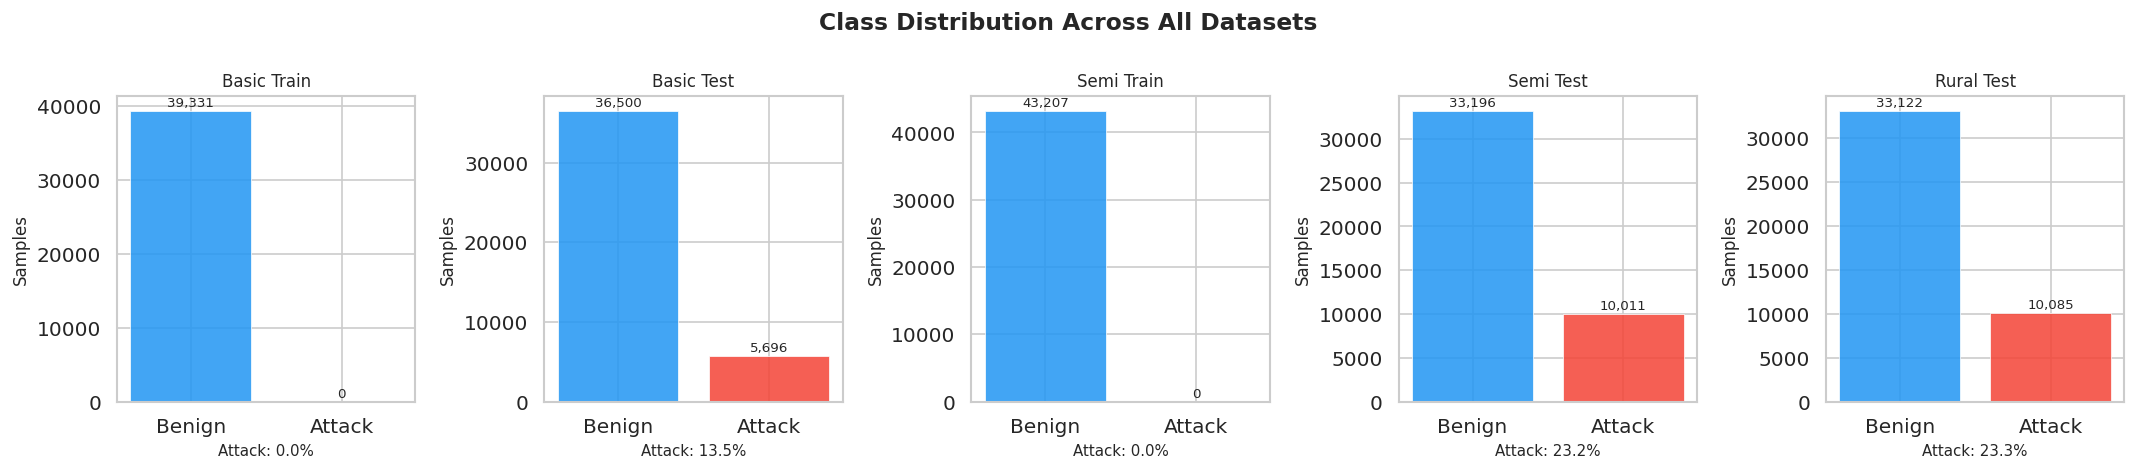

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (name, df) in zip(axes, dfs.items()):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(
        ['Benign', 'Attack'],
        [counts.get(0, 0), counts.get(1, 0)],
        color=[CLR['benign'], CLR['attack']],
        alpha=0.85, edgecolor='white', linewidth=0.5
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 200,
                f'{h:,}', ha='center', va='bottom', fontsize=8)
    ax.set_title(name.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Samples')
    total = len(df)
    pct_atk = 100.0 * counts.get(1, 0) / total
    ax.set_xlabel(f'Attack: {pct_atk:.1f}%', fontsize=9)

fig.suptitle('Class Distribution Across All Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

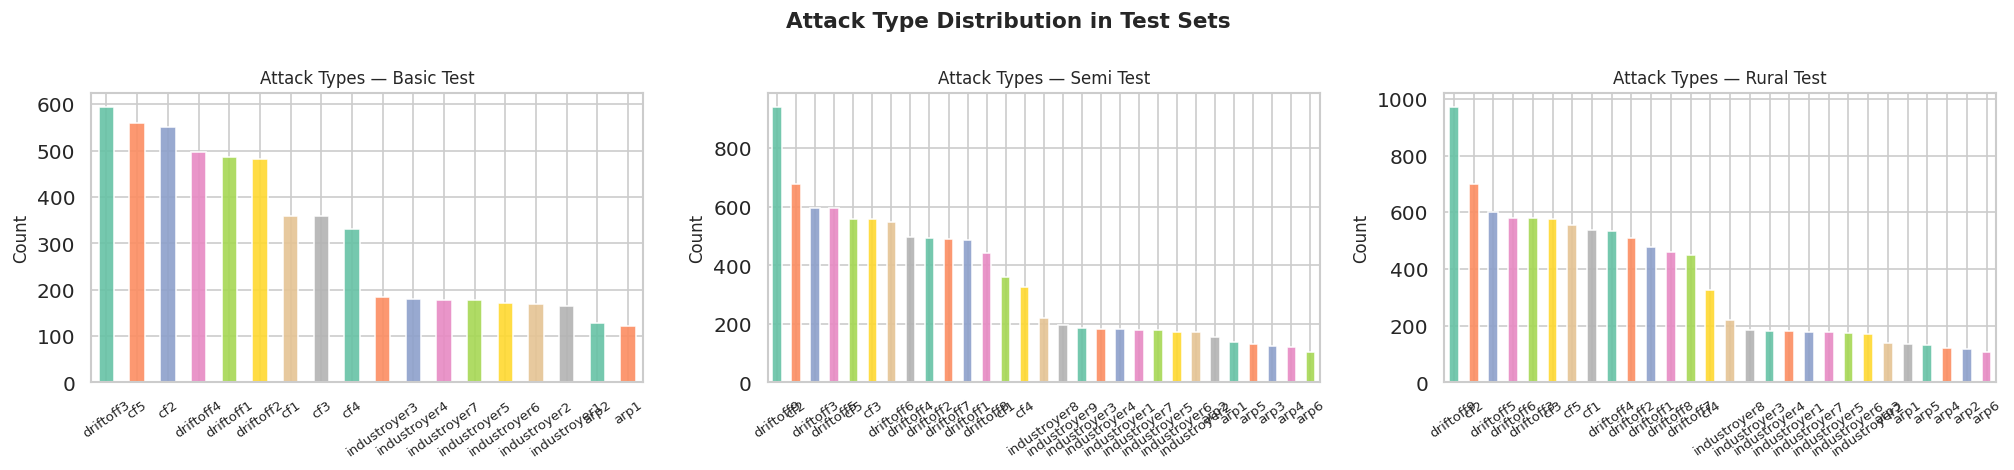

In [17]:
# ── Attack type breakdown in test sets ───────────────────────────────────────
if 'attack_type' in dfs['basic_test'].columns:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    test_names = ['basic_test', 'semi_test', 'rural_test']

    for ax, name in zip(axes, test_names):
        df_atk = dfs[name][dfs[name]['label'] == 1]
        if len(df_atk) == 0:
            ax.text(0.5, 0.5, 'No attacks', transform=ax.transAxes, ha='center')
            continue
        counts = df_atk['attack_type'].value_counts()
        counts.plot.bar(ax=ax, color=sns.color_palette('Set2', len(counts)),
                        edgecolor='white', alpha=0.9)
        ax.set_title(f'Attack Types — {name.replace("_", " ").title()}', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=35, labelsize=8)

    fig.suptitle('Attack Type Distribution in Test Sets', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [18]:
FEATURE_COLS = [
    'bytes', 'packets', 'packets_per_sec',
    'packet_size_mean', 'packet_size_std', 'packet_size_min', 'packet_size_max',
    'syn_ratio', 'ack_ratio', 'fin_ratio', 'rst_ratio', 'psh_ratio',
    'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports',
    'src_ip_entropy', 'dst_ip_entropy', 'dst_port_entropy',
    'tcp_ratio', 'udp_ratio', 'icmp_ratio'
]

# Keep only columns that exist in the dataset
all_data = pd.concat(dfs.values(), ignore_index=True)
FEATURE_COLS = [c for c in FEATURE_COLS if c in all_data.columns]
print(f'Active feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# Combined test data (has both classes)
test_all = pd.concat(
    [dfs['basic_test'], dfs['semi_test'], dfs['rural_test']],
    ignore_index=True
)

print('\nFeature Statistics — Benign vs Attack (Combined Test Sets)')
print('=' * 72)
stat_rows = []
for feat in FEATURE_COLS:
    b = test_all[test_all['label'] == 0][feat].describe()
    a = test_all[test_all['label'] == 1][feat].describe()
    stat_rows.append({
        'Feature':        feat,
        'Benign Mean':    round(b['mean'], 4),
        'Benign Std':     round(b['std'],  4),
        'Attack Mean':    round(a['mean'], 4),
        'Attack Std':     round(a['std'],  4),
        'Mean Δ':         round(abs(a['mean'] - b['mean']), 4),
    })
stats_df = pd.DataFrame(stat_rows).sort_values('Mean Δ', ascending=False)
display(stats_df.to_string(index=False))

Active feature columns (21): ['bytes', 'packets', 'packets_per_sec', 'packet_size_mean', 'packet_size_std', 'packet_size_min', 'packet_size_max', 'syn_ratio', 'ack_ratio', 'fin_ratio', 'rst_ratio', 'psh_ratio', 'unique_src_ips', 'unique_dst_ips', 'unique_dst_ports', 'src_ip_entropy', 'dst_ip_entropy', 'dst_port_entropy', 'tcp_ratio', 'udp_ratio', 'icmp_ratio']

Feature Statistics — Benign vs Attack (Combined Test Sets)


'         Feature  Benign Mean  Benign Std  Attack Mean  Attack Std    Mean Δ\n           bytes   10539.8543   7622.9713   12426.7628   7124.6040 1886.9084\n         packets     120.6982     87.4952     142.7354     81.2333   22.0372\n packets_per_sec     120.6982     87.4952     142.7354     81.2333   22.0372\n packet_size_max     224.3760     75.4366     236.1910     73.0530   11.8150\n packet_size_min      66.0390      1.1063      59.2992     10.7668    6.7397\n  unique_src_ips      23.9198     13.9765      27.9908     13.3578    4.0710\n  unique_dst_ips      19.4458     11.4580      22.7533     11.4144    3.3075\nunique_dst_ports      19.4558     11.4419      22.3910     11.3075    2.9352\npacket_size_mean      87.8066     10.6166      86.5820      8.1848    1.2246\n packet_size_std      35.0947     15.8956      35.3980     13.9627    0.3034\n  src_ip_entropy       3.2614      0.8164       3.5122      0.6928    0.2508\n  dst_ip_entropy       2.7733      0.6214       2.9422      0.5

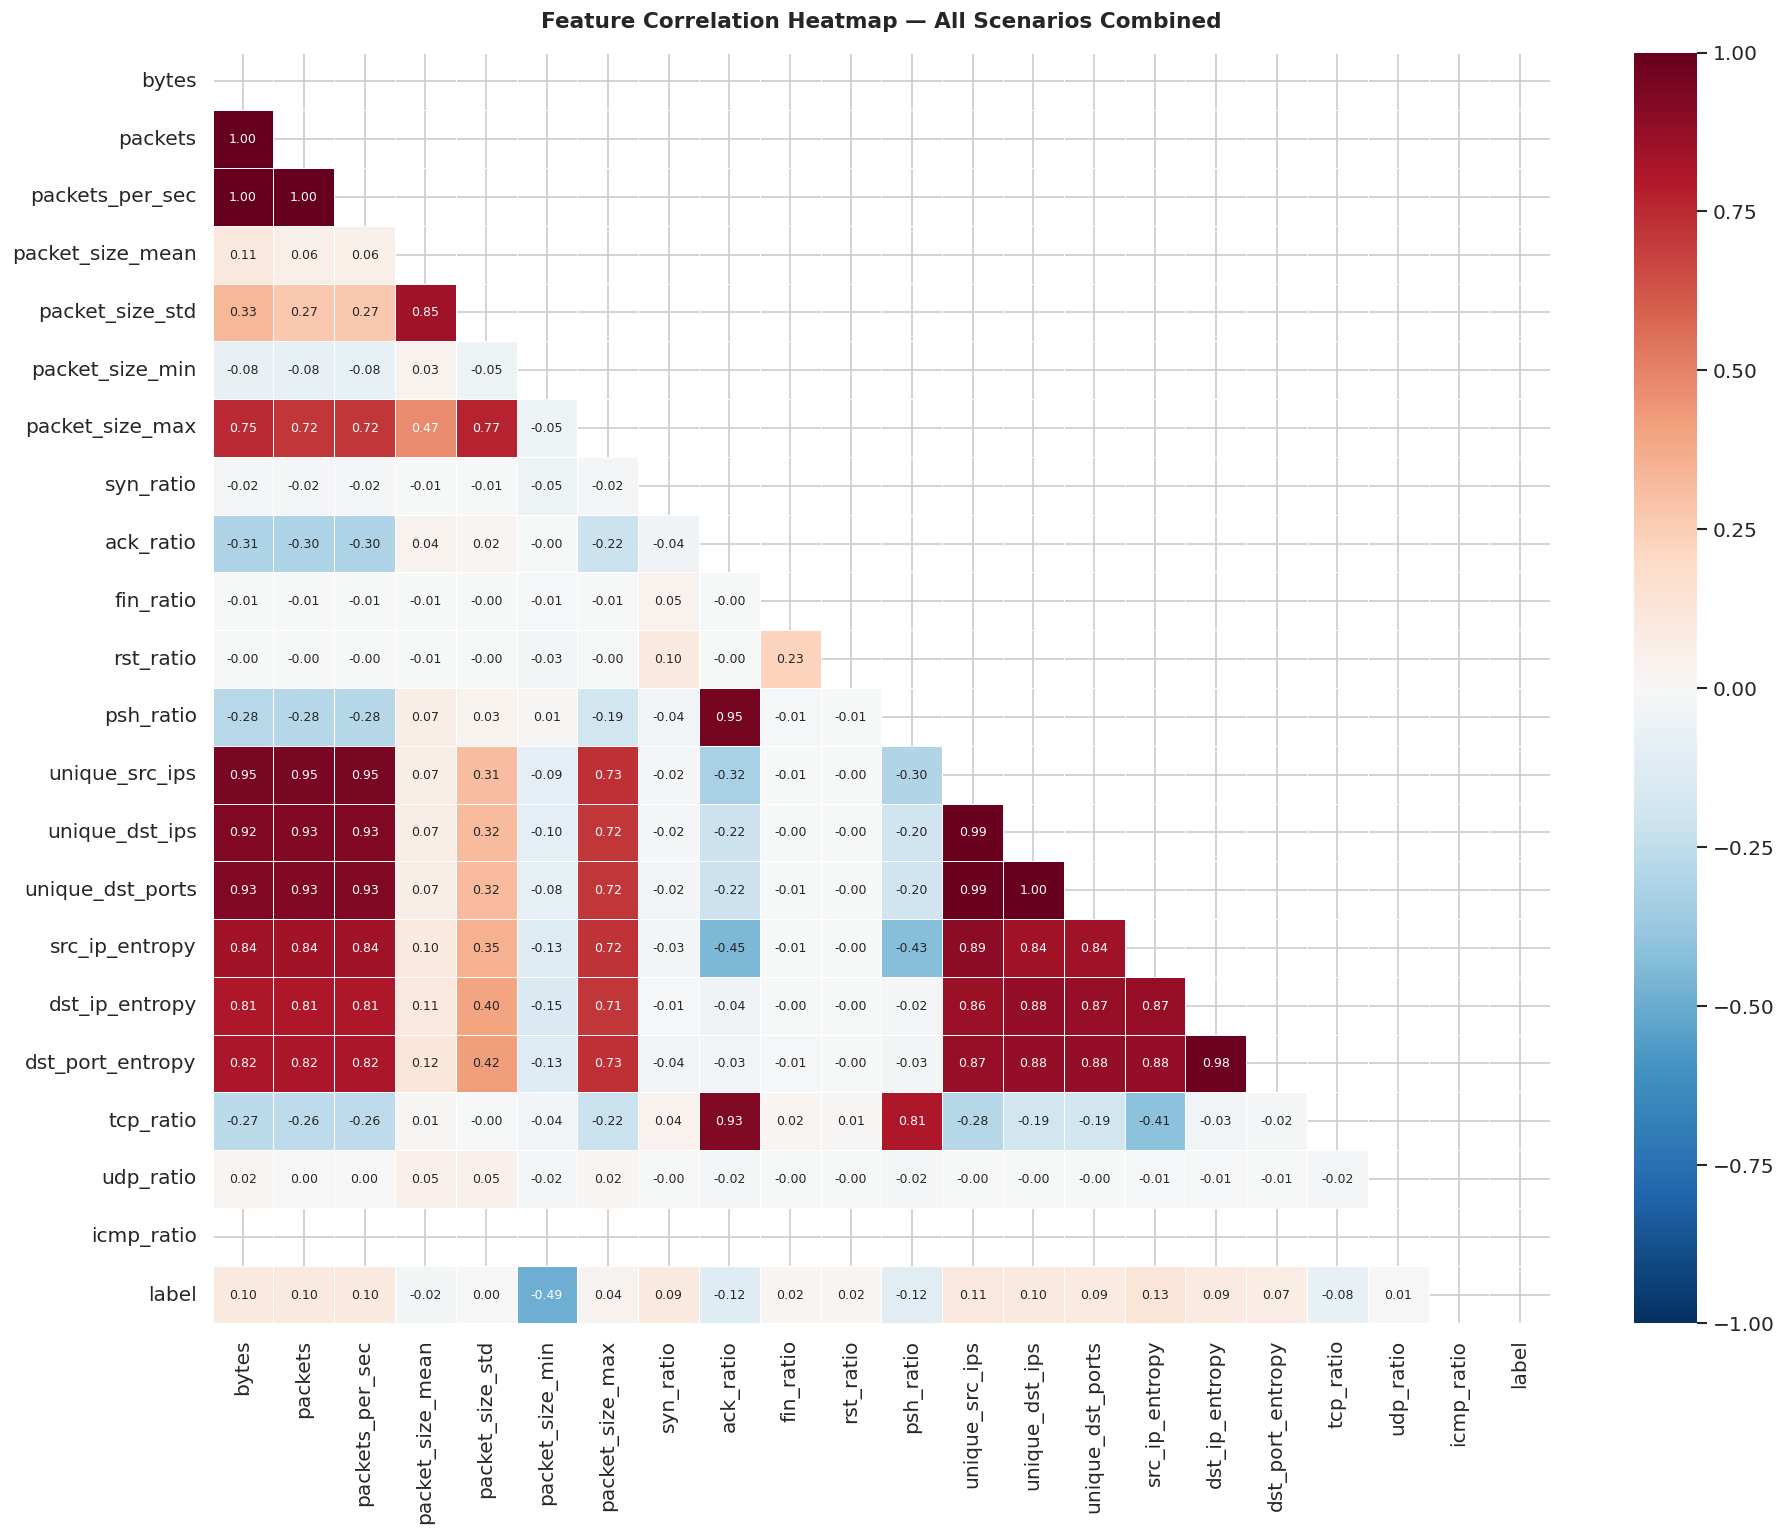


Top 10 features correlated with label:
packet_size_min    0.487836
src_ip_entropy     0.128145
ack_ratio          0.124221
psh_ratio          0.117123
unique_src_ips     0.108845
packets            0.098842
packets_per_sec    0.098842
unique_dst_ips     0.098148
bytes              0.095206
syn_ratio          0.094130


In [19]:
corr = all_data[FEATURE_COLS + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 7.5}
)
ax.set_title('Feature Correlation Heatmap — All Scenarios Combined',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with label
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print('\nTop 10 features correlated with label:')
print(label_corr.head(10).to_string())

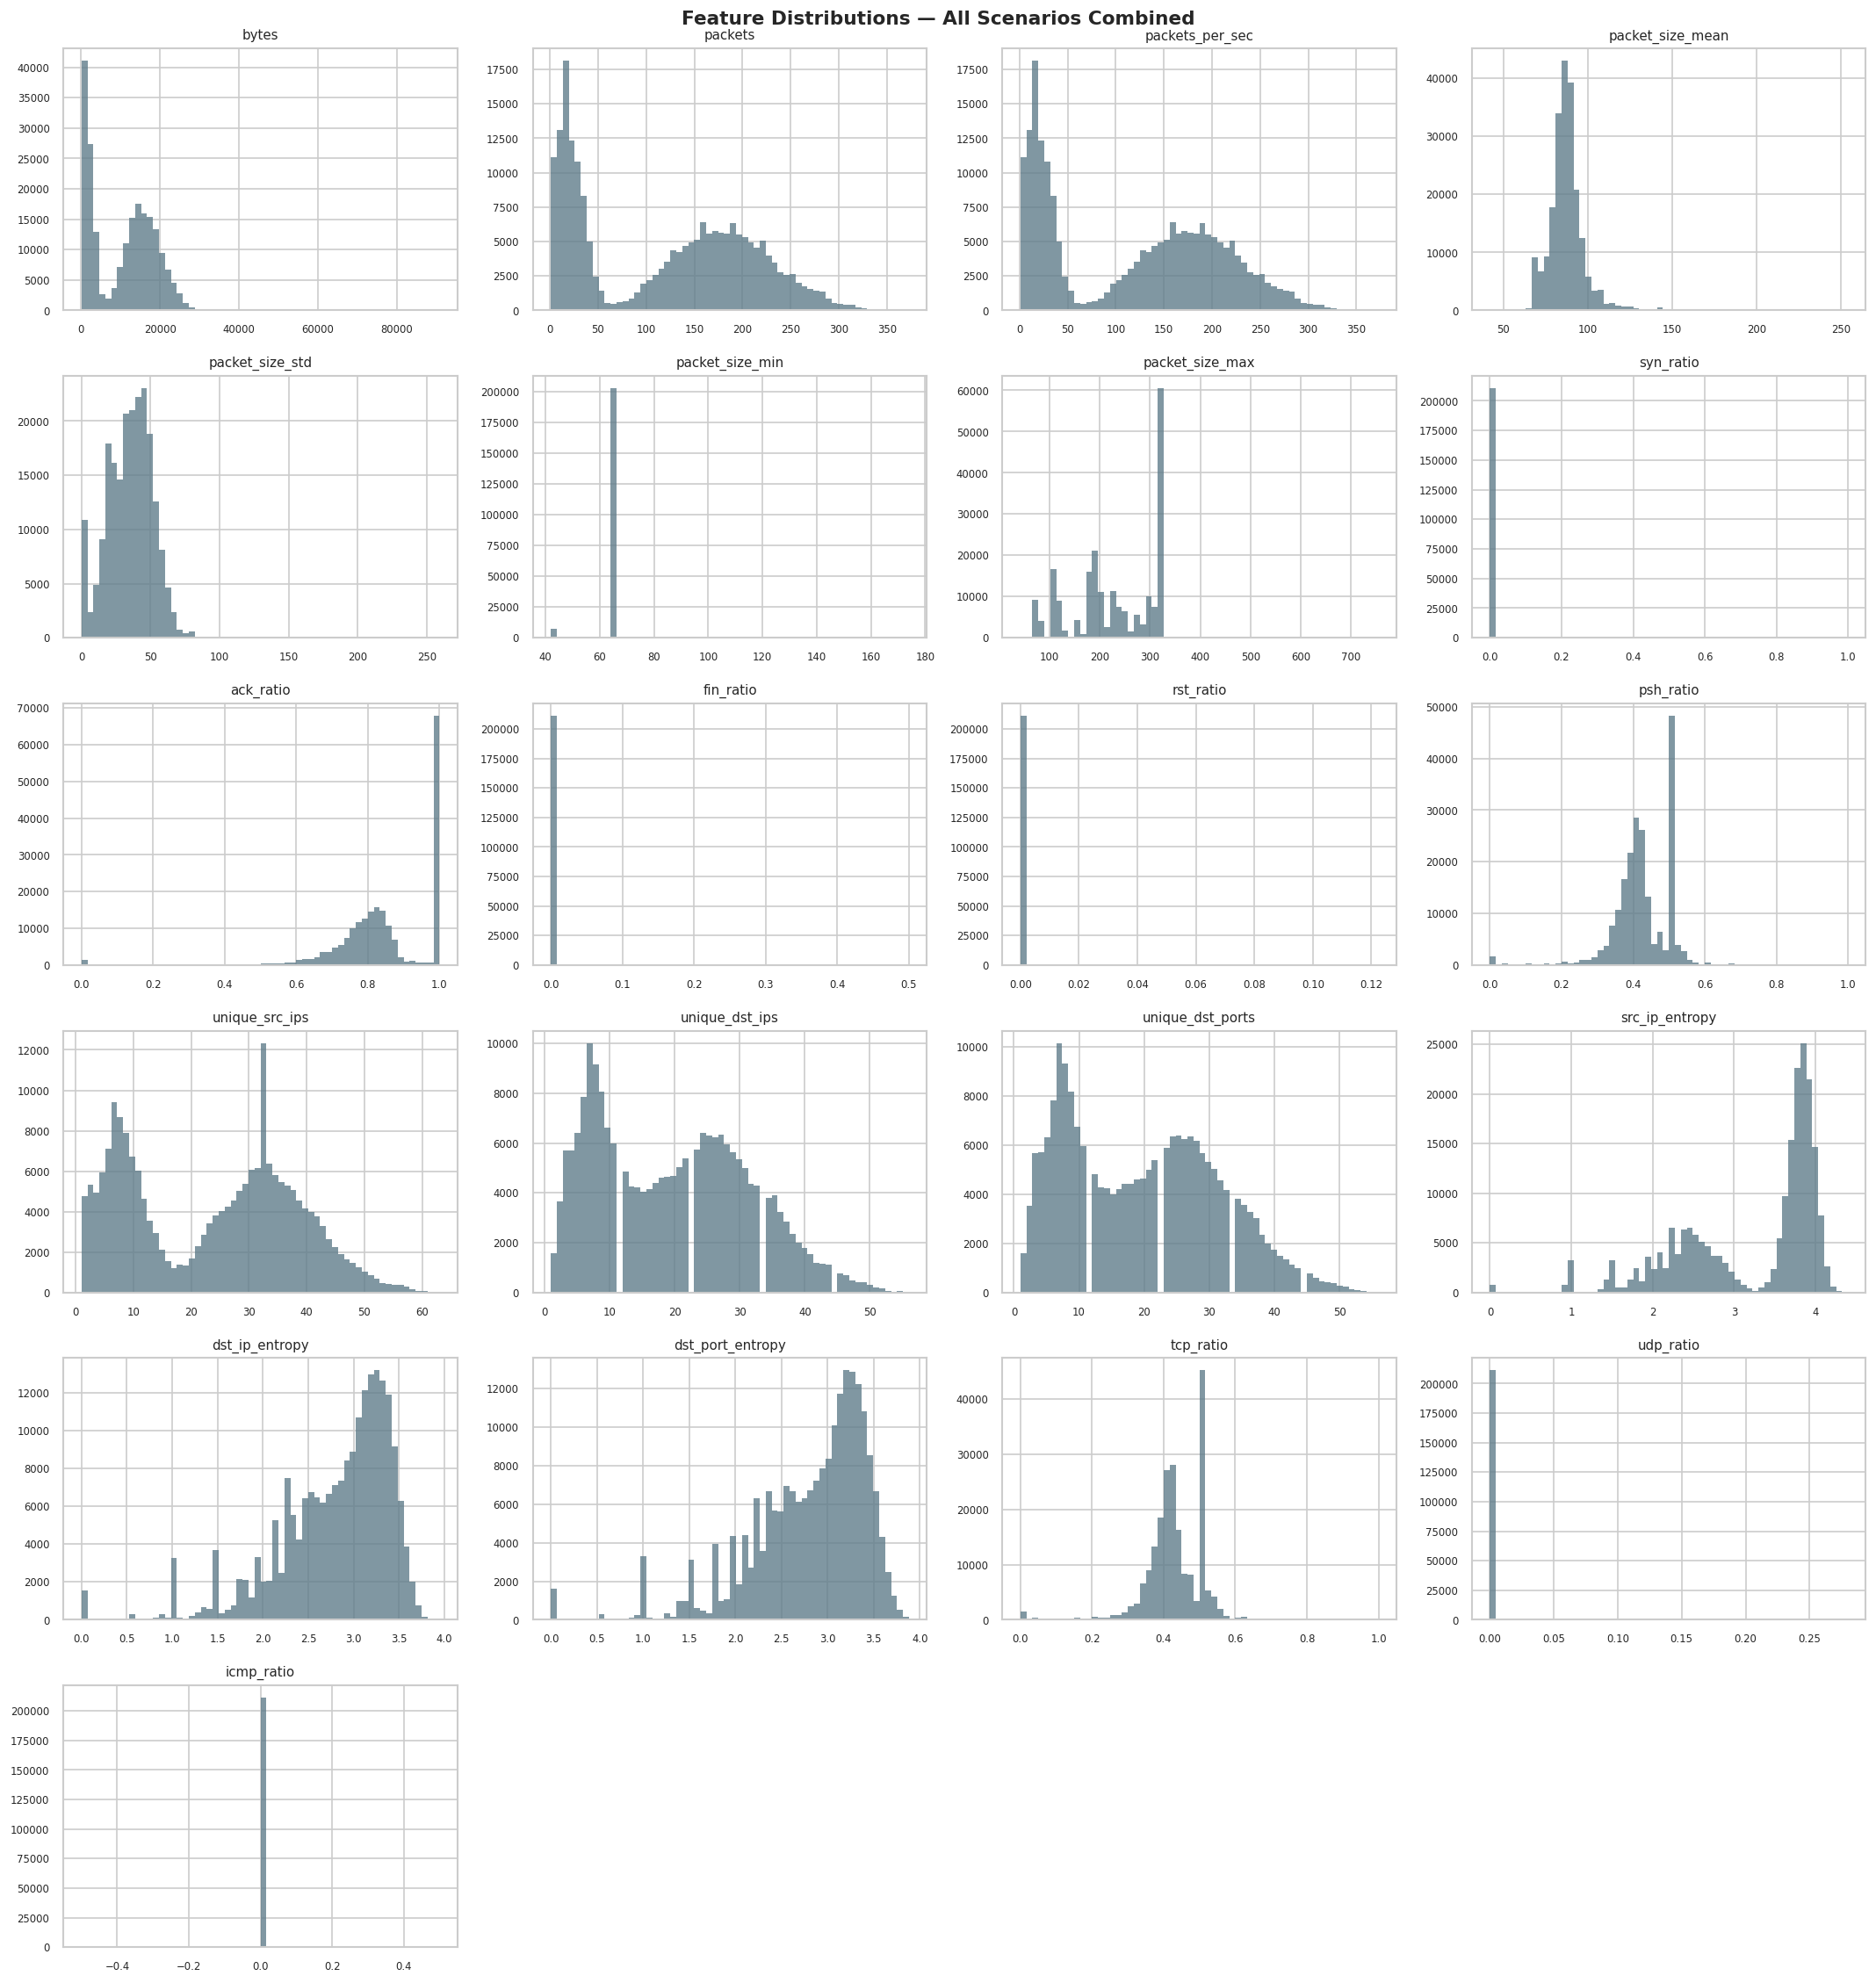

In [20]:
N_COLS  = 4
N_ROWS  = int(np.ceil(len(FEATURE_COLS) / N_COLS))
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, N_ROWS * 3.2))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    data = all_data[feat].dropna()
    axes[i].hist(data, bins=60, color=CLR['neutral'],
                 edgecolor='none', alpha=0.8)
    axes[i].set_title(feat, fontsize=9)
    axes[i].tick_params(labelsize=7)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions — All Scenarios Combined',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

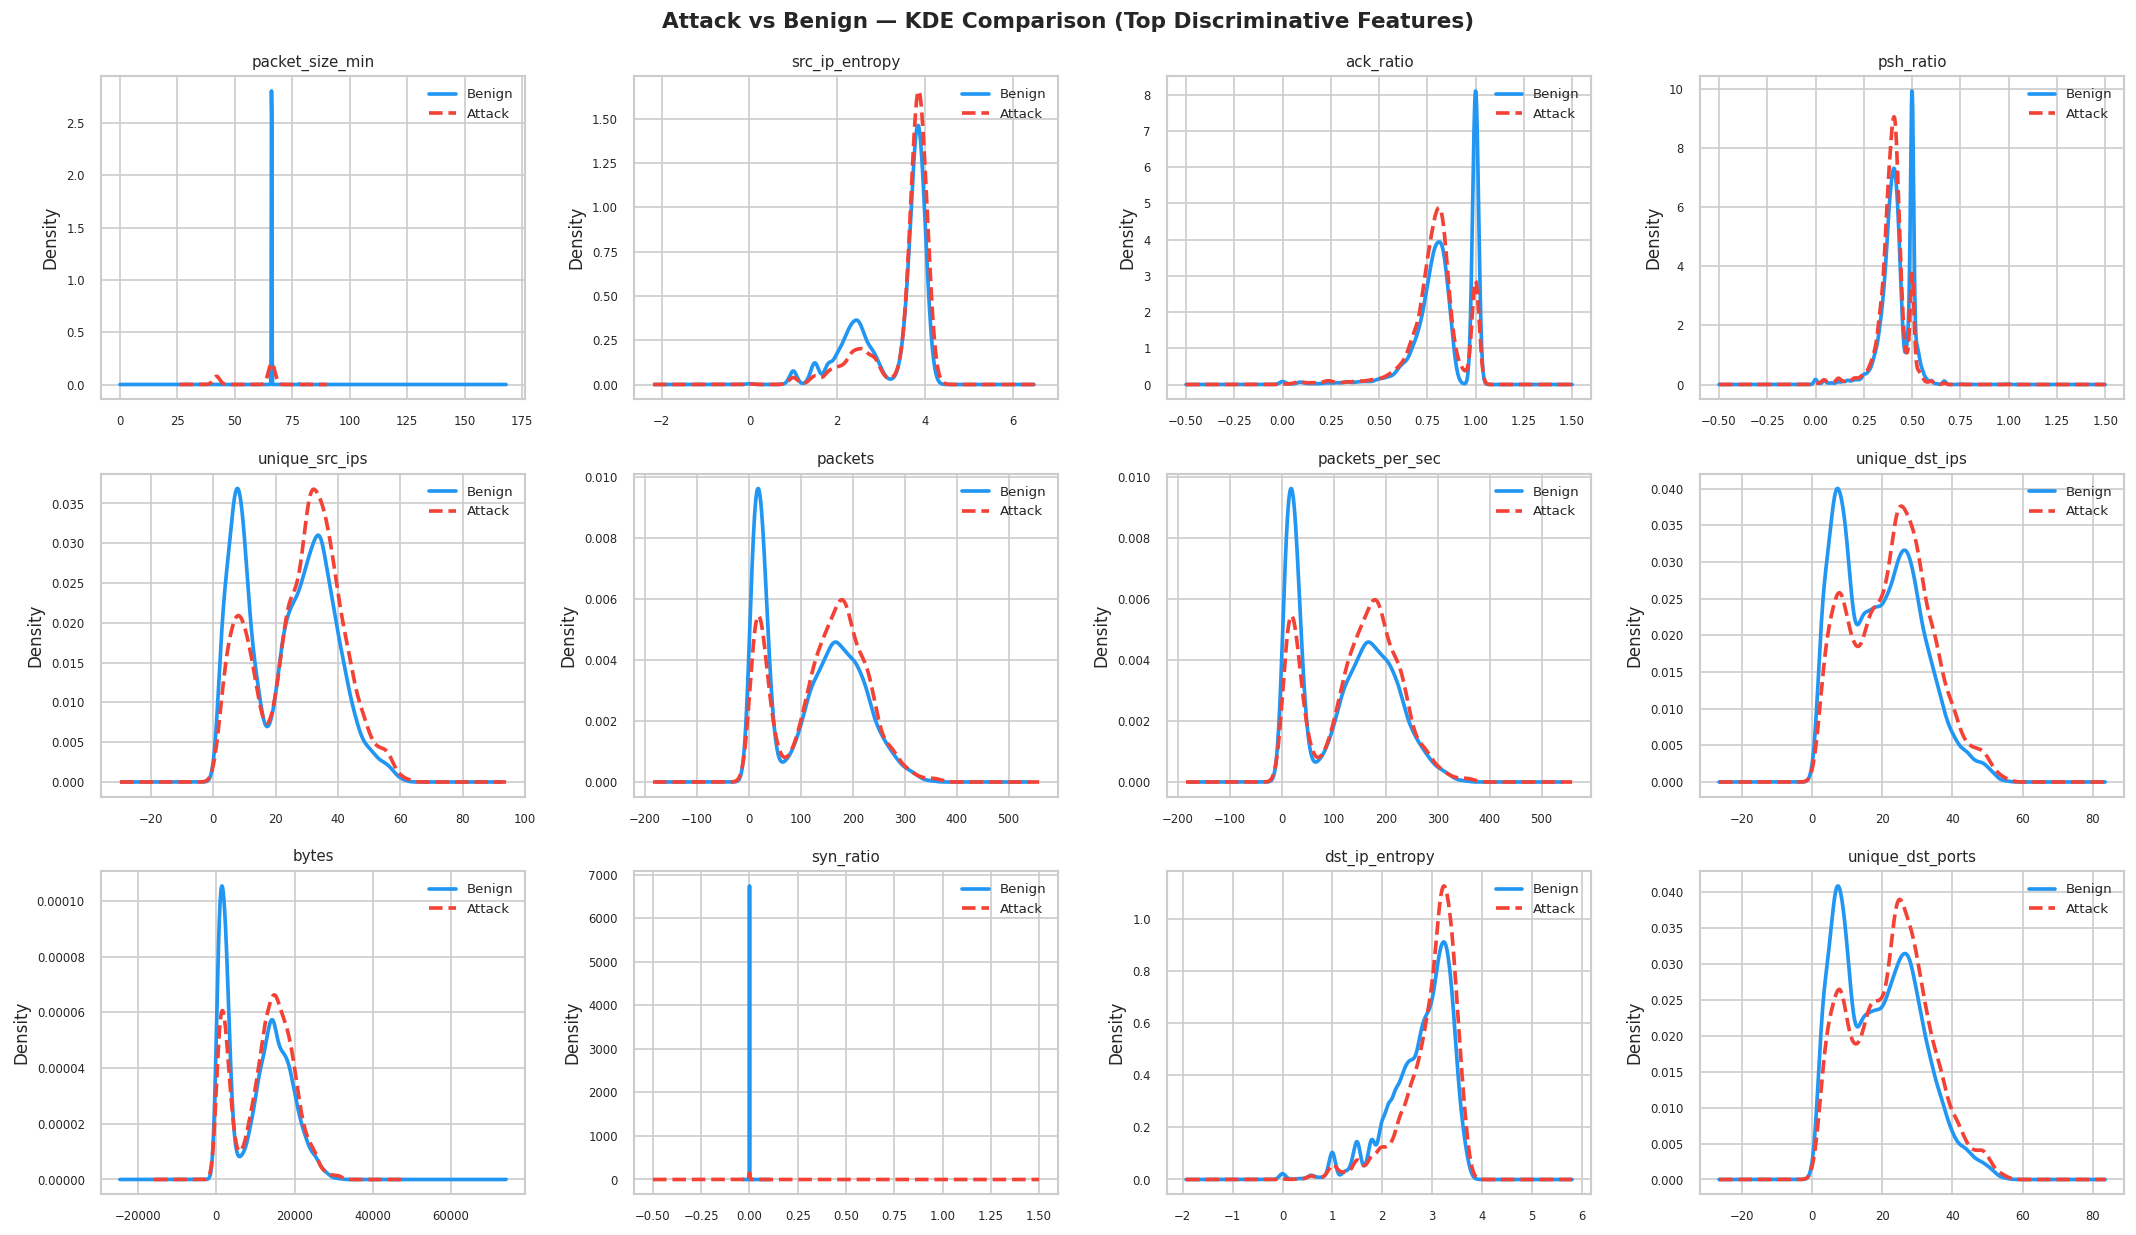

In [21]:

# KDE overlays: top 12 most discriminative features
top_feats = label_corr.head(12).index.tolist()
N_COLS = 4
N_ROWS = int(np.ceil(len(top_feats) / N_COLS))
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, N_ROWS * 3.5))
axes = axes.flatten()

benign_df = test_all[test_all['label'] == 0]
attack_df = test_all[test_all['label'] == 1]

for i, feat in enumerate(top_feats):
    ax = axes[i]
    b  = benign_df[feat].dropna()
    a  = attack_df[feat].dropna()
    if len(b) > 1:
        b.plot.kde(ax=ax, color=CLR['benign'], linewidth=2.2, label='Benign')
    if len(a) > 1:
        a.plot.kde(ax=ax, color=CLR['attack'], linewidth=2.2,
                   linestyle='--', label='Attack')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Attack vs Benign — KDE Comparison (Top Discriminative Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
print(network_data['basic_test']['attack_type'].value_counts())
print(network_data['basic_test']['label'].value_counts())

attack_type
benign    42196
Name: count, dtype: int64
label
0    42196
Name: count, dtype: int64


In [23]:
# ═══════════════════════════════════════════════════════════
# DATA PREPARATION — COMPLETE PIPELINE
# ═══════════════════════════════════════════════════════════
import numpy as np, json
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# ── Step 0: Fix basic_test labels first ────────────────────
def regenerate_basic_test_labels(df, events_path, tolerance_sec=2.0):
    events = []
    with open(events_path) as f:
        for line in f:
            line = line.strip()
            if line:
                events.append(json.loads(line))
    mal = [e for e in events
           if e.get('notification_data', {}).get('malicious') is True]
    starts, intervals = {}, []
    for e in sorted(mal, key=lambda x: x.get('timestamp', 0)):
        nd   = e.get('notification_data', {})
        mark = nd.get('mark', '').lower()
        ts   = float(e.get('timestamp', 0))
        eid  = nd.get('id', '')
        ref  = nd.get('reference_id', '')
        if mark == 'start':
            starts[eid] = ts
        elif mark == 'end':
            mid = ref if ref in starts else (eid if eid in starts else None)
            if mid:
                intervals.append((starts.pop(mid), ts))
    print(f'  basic_test attack intervals: {len(intervals)}')
    ts_vals = df['ts'].values
    labels  = np.zeros(len(ts_vals), dtype=int)
    for t_start, t_end in intervals:
        mask = (ts_vals >= t_start - tolerance_sec) & \
               (ts_vals <= t_end   + tolerance_sec)
        labels[mask] = 1
    df = df.copy()
    df['label'] = labels
    df['attack_type'] = np.where(labels == 1, 'attack', 'benign')
    print(f'  basic_test attacks labeled: {labels.sum():,} / {len(df):,} ({100*labels.mean():.1f}%)')
    return df

BASIC_TEST_EVENTS = Path(
    '/kaggle/input/datasets/ayuusss/sherlock/'
    '01-Basic/01-Basic/raw/test/events.jsonl'
)
print('Step 0: Fixing basic_test labels ...')
network_data['basic_test'] = regenerate_basic_test_labels(
    network_data['basic_test'], BASIC_TEST_EVENTS, tolerance_sec=2.0
)

# ── Step 1: Scaler — fit on train only ─────────────────────
print('\nStep 1: Fitting scaler ...')
train_df = pd.concat(
    [network_data['basic_train'], network_data['semi_train']],
    ignore_index=True
).sort_values('ts').reset_index(drop=True)

scaler = StandardScaler()
scaler.fit(train_df[FEATURE_COLS].fillna(0).values)
print(f'  Fit on {len(train_df):,} samples | attacks={int(train_df["label"].sum())} (expected 0)')

# ── Step 2: test_splits_sc ─────────────────────────────────
print('\nStep 2: Building test splits ...')
test_splits_sc = {}
for name in ['basic_test', 'semi_test', 'rural_test']:
    df_s = network_data[name].sort_values('ts').reset_index(drop=True)
    X_s  = scaler.transform(df_s[FEATURE_COLS].fillna(0).values)
    y_s  = df_s['label'].values.astype(int)
    test_splits_sc[name] = (X_s, y_s)
    print(f'  {name:15s} → {X_s.shape}  attacks={y_s.sum():,}')

# ── Step 3: Augmented ML training set ──────────────────────
print('\nStep 3: Building ML training set ...')
X_train_sc = scaler.transform(train_df[FEATURE_COLS].fillna(0).values)
y_train    = train_df['label'].values.astype(int)

aug_X = [X_train_sc]
aug_y = [y_train]

for name, (Xs, ys) in test_splits_sc.items():
    atk_idx = np.where(ys == 1)[0]
    if len(atk_idx) == 0:
        print(f'  {name:15s} → skipped (0 attacks)')
        continue
    n_sample = max(1, len(atk_idx) // 5)
    chosen   = np.random.RandomState(RANDOM_SEED).choice(
                   atk_idx, size=n_sample, replace=False)
    aug_X.append(Xs[chosen])
    aug_y.append(ys[chosen])
    print(f'  {name:15s} → borrowed {n_sample:,} attack samples')

X_aug_ml = np.vstack(aug_X)
y_aug_ml = np.concatenate(aug_y)
X_aug    = X_aug_ml
y_aug    = y_aug_ml

n_benign   = int((y_aug_ml == 0).sum())
n_attack   = int((y_aug_ml == 1).sum())
actual_spw = n_benign / n_attack

print(f'\n✅ ML Training set ready:')
print(f'  Total  : {len(X_aug_ml):,}')
print(f'  Benign : {n_benign:,}')
print(f'  Attack : {n_attack:,}  ({100*n_attack/len(X_aug_ml):.1f}%)')
print(f'  SPW    : {actual_spw:.2f}')

Step 0: Fixing basic_test labels ...
  basic_test attack intervals: 19
  basic_test attacks labeled: 5,772 / 42,196 (13.7%)

Step 1: Fitting scaler ...
  Fit on 82,538 samples | attacks=0 (expected 0)

Step 2: Building test splits ...
  basic_test      → (42196, 21)  attacks=5,772
  semi_test       → (43207, 21)  attacks=10,011
  rural_test      → (43207, 21)  attacks=10,085

Step 3: Building ML training set ...
  basic_test      → borrowed 1,154 attack samples
  semi_test       → borrowed 2,002 attack samples
  rural_test      → borrowed 2,017 attack samples

✅ ML Training set ready:
  Total  : 87,711
  Benign : 82,538
  Attack : 5,173  (5.9%)
  SPW    : 15.96


In [24]:
# ── IMPROVED MODEL DEFINITIONS ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Count actual class distribution in training data
n_benign = int((y_aug == 0).sum())
n_attack = int((y_aug == 1).sum())
actual_spw = n_benign / n_attack
print(f'Actual scale_pos_weight from train data: {actual_spw:.2f}')
print(f'  n_benign={n_benign:,}  n_attack={n_attack:,}')

models = {
    'Logistic Regression': LogisticRegression(
        C=0.1,                    # stronger regularization
        max_iter=2000,
        class_weight='balanced',
        solver='saga',            # better for large datasets
        random_state=RANDOM_SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,       # slower learning
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=3,
        gamma=0.1,                # regularization
        reg_alpha=0.1,            # L1
        reg_lambda=1.0,           # L2
        scale_pos_weight=actual_spw,  # actual ratio from data
        use_label_encoder=False,
        eval_metric='aucpr',      # PR-AUC better for imbalanced
        n_jobs=-1,
        verbosity=0,
        random_state=RANDOM_SEED
    ),
}

print('\nModels re-initialised with improved hyperparameters.')

Actual scale_pos_weight from train data: 15.96
  n_benign=82,538  n_attack=5,173

Models re-initialised with improved hyperparameters.


In [25]:
import time
from sklearn.metrics import f1_score

# ── Retrain ────────────────────────────────────────────────────────────────
trained_models = {}
train_times    = {}

print('Retraining improved models ...')
print(f'  Samples: {X_aug.shape[0]:,}  |  Features: {X_aug.shape[1]}')
print(f'  Attacks: {int(y_aug.sum()):,}  ({100*y_aug.mean():.1f}%)\n')

for name, model in models.items():
    t0 = time.time()
    model.fit(X_aug, y_aug)
    elapsed = time.time() - t0
    trained_models[name] = model
    train_times[name] = round(elapsed, 2)
    print(f'  ✅ {name:25s} trained in {elapsed:.2f}s')


# ── Per-scenario optimal threshold ────────────────────────────────────────
def find_best_threshold(model, X, y):
    """Find threshold that maximises F1 on given data."""
    y_score = model.predict_proba(X)[:, 1]
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        yp = (y_score >= t).astype(int)
        sc = f1_score(y, yp, zero_division=0)
        if sc > best_f1:
            best_f1, best_t = sc, t
    return best_t, best_f1


print('\n\nOptimal Thresholds per Scenario:')
print('=' * 55)
optimal_thresholds = {}   # {model_name: {scenario: threshold}}

for mname, mdl in trained_models.items():
    optimal_thresholds[mname] = {}
    print(f'\n  {mname}')
    for scenario, (Xs, ys) in test_splits_sc.items():
        t, f1 = find_best_threshold(mdl, Xs, ys)
        optimal_thresholds[mname][scenario] = t
        print(f'    {scenario:15s} → threshold={t:.2f}  F1={f1:.4f}')

Retraining improved models ...
  Samples: 87,711  |  Features: 21
  Attacks: 5,173  (5.9%)

  ✅ Logistic Regression       trained in 72.66s
  ✅ Random Forest             trained in 18.97s
  ✅ XGBoost                   trained in 2.53s


Optimal Thresholds per Scenario:

  Logistic Regression
    basic_test      → threshold=0.92  F1=0.3848
    semi_test       → threshold=0.74  F1=0.4400
    rural_test      → threshold=0.92  F1=0.3975

  Random Forest
    basic_test      → threshold=0.88  F1=0.3976
    semi_test       → threshold=0.73  F1=0.5530
    rural_test      → threshold=0.94  F1=0.4372

  XGBoost
    basic_test      → threshold=0.94  F1=0.3398
    semi_test       → threshold=0.83  F1=0.4890
    rural_test      → threshold=0.94  F1=0.3947


In [26]:
def evaluate(model, X_test: np.ndarray, y_test: np.ndarray,
             model_name: str, scenario: str) -> dict:
    """
    Evaluate a trained binary classifier.

    Returns a dict with all standard IDS metrics plus
    raw predictions and scores for downstream plotting.
    """
    y_pred  = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    n_unique = len(np.unique(y_test))
    roc_auc  = roc_auc_score(y_test, y_score) if n_unique > 1 else float('nan')
    ap       = average_precision_score(y_test, y_score) if n_unique > 1 else float('nan')

    # Detected Attacks & False Alarms from confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (cm[0, 0], 0, 0, 0)

    return {
        'model':      model_name,
        'scenario':   scenario,
        'accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'precision':  round(precision_score(y_test, y_pred, zero_division=0), 4),
        'recall':     round(recall_score(y_test, y_pred, zero_division=0), 4),
        'f1':         round(f1_score(y_test, y_pred, zero_division=0), 4),
        'roc_auc':    round(roc_auc, 4),
        'avg_prec':   round(ap, 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
        'detected_attacks': int(tp),
        'false_alarms':     int(fp),
        'y_pred':  y_pred,
        'y_score': y_score,
        'y_true':  y_test,
    }


# ── Run evaluation ────────────────────────────────────────────────────────────
results = {}

for scenario, (Xs, ys) in test_splits_sc.items():
    results[scenario] = {}
    print(f'\n  ── {scenario} ──')
    for mname, mdl in trained_models.items():
        r = evaluate(mdl, Xs, ys, mname, scenario)
        results[scenario][mname] = r
        print(f'    {mname:25s} | Acc={r["accuracy"]:.4f}  '
              f'P={r["precision"]:.4f}  R={r["recall"]:.4f}  '
              f'F1={r["f1"]:.4f}  AUC={r["roc_auc"]:.4f}')

print('\n✅ Evaluation complete.')


  ── basic_test ──
    Logistic Regression       | Acc=0.7553  P=0.2724  R=0.4721  F1=0.3455  AUC=0.6748
    Random Forest             | Acc=0.5936  P=0.2209  R=0.7801  F1=0.3444  AUC=0.7406
    XGBoost                   | Acc=0.4612  P=0.1822  R=0.8422  F1=0.2995  AUC=0.7328

  ── semi_test ──
    Logistic Regression       | Acc=0.5507  P=0.2978  R=0.6915  F1=0.4163  AUC=0.6731
    Random Forest             | Acc=0.7132  P=0.4273  R=0.6982  F1=0.5301  AUC=0.7966
    XGBoost                   | Acc=0.5488  P=0.3214  R=0.8520  F1=0.4667  AUC=0.7592

  ── rural_test ──
    Logistic Regression       | Acc=0.2481  P=0.2346  R=0.9822  F1=0.3788  AUC=0.6532
    Random Forest             | Acc=0.2903  P=0.2458  R=0.9862  F1=0.3935  AUC=0.6966
    XGBoost                   | Acc=0.2623  P=0.2401  R=0.9976  F1=0.3870  AUC=0.6885

✅ Evaluation complete.


In [27]:
# ── Classification Reports ────────────────────────────────────────────────────
for scenario, model_dict in results.items():
    for mname, r in model_dict.items():
        print('=' * 62)
        print(f'  {mname}  |  {scenario}')
        print('=' * 62)
        print(classification_report(
            r['y_true'], r['y_pred'],
            target_names=['Benign', 'Attack'],
            zero_division=0
        ))

  Logistic Regression  |  basic_test
              precision    recall  f1-score   support

      Benign       0.91      0.80      0.85     36424
      Attack       0.27      0.47      0.35      5772

    accuracy                           0.76     42196
   macro avg       0.59      0.64      0.60     42196
weighted avg       0.82      0.76      0.78     42196

  Random Forest  |  basic_test
              precision    recall  f1-score   support

      Benign       0.94      0.56      0.71     36424
      Attack       0.22      0.78      0.34      5772

    accuracy                           0.59     42196
   macro avg       0.58      0.67      0.52     42196
weighted avg       0.84      0.59      0.66     42196

  XGBoost  |  basic_test
              precision    recall  f1-score   support

      Benign       0.94      0.40      0.56     36424
      Attack       0.18      0.84      0.30      5772

    accuracy                           0.46     42196
   macro avg       0.56      0.62  

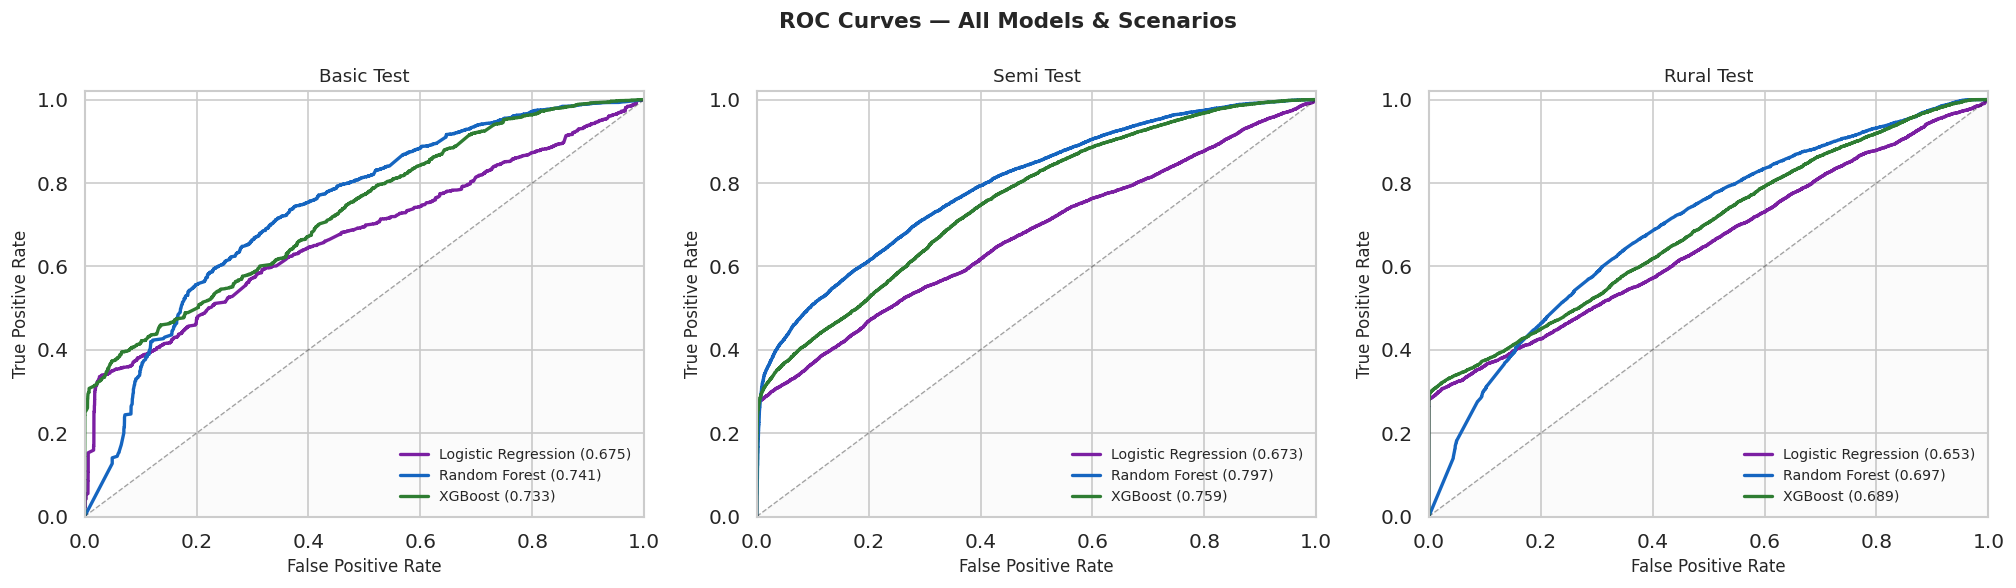

In [28]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
model_colors = {
    'Logistic Regression': CLR['lr'],
    'Random Forest':       CLR['rf'],
    'XGBoost':             CLR['xgb'],
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, scenario in zip(axes, results.keys()):
    for mname, r in results[scenario].items():
        if np.isnan(r['roc_auc']):
            continue
        fpr, tpr, _ = roc_curve(r['y_true'], r['y_score'])
        ax.plot(fpr, tpr,
                label=f"{mname} ({r['roc_auc']:.3f})",
                color=model_colors[mname], linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
    ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.03, color='grey')
    ax.set_title(scenario.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8.5, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

fig.suptitle('ROC Curves — All Models & Scenarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

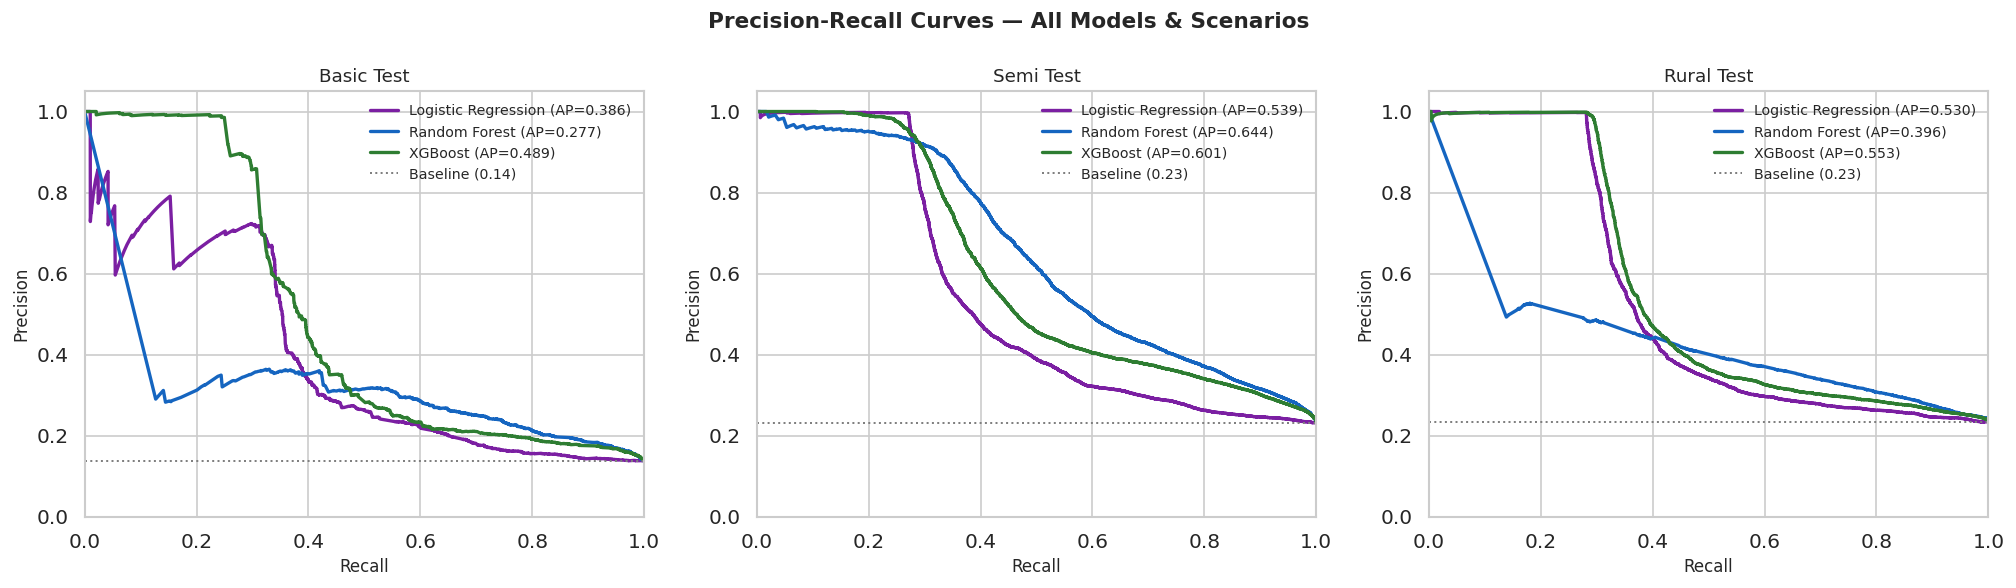

In [29]:
# ── Precision-Recall Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, scenario in zip(axes, results.keys()):
    for mname, r in results[scenario].items():
        if np.isnan(r['avg_prec']):
            continue
        prec, rec, _ = precision_recall_curve(r['y_true'], r['y_score'])
        ax.plot(rec, prec,
                label=f"{mname} (AP={r['avg_prec']:.3f})",
                color=model_colors[mname], linewidth=2)
    baseline = r['y_true'].mean()
    ax.axhline(baseline, color='grey', linestyle=':', linewidth=1.2,
               label=f'Baseline ({baseline:.2f})')
    ax.set_title(scenario.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=8.5, loc='upper right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

fig.suptitle('Precision-Recall Curves — All Models & Scenarios',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

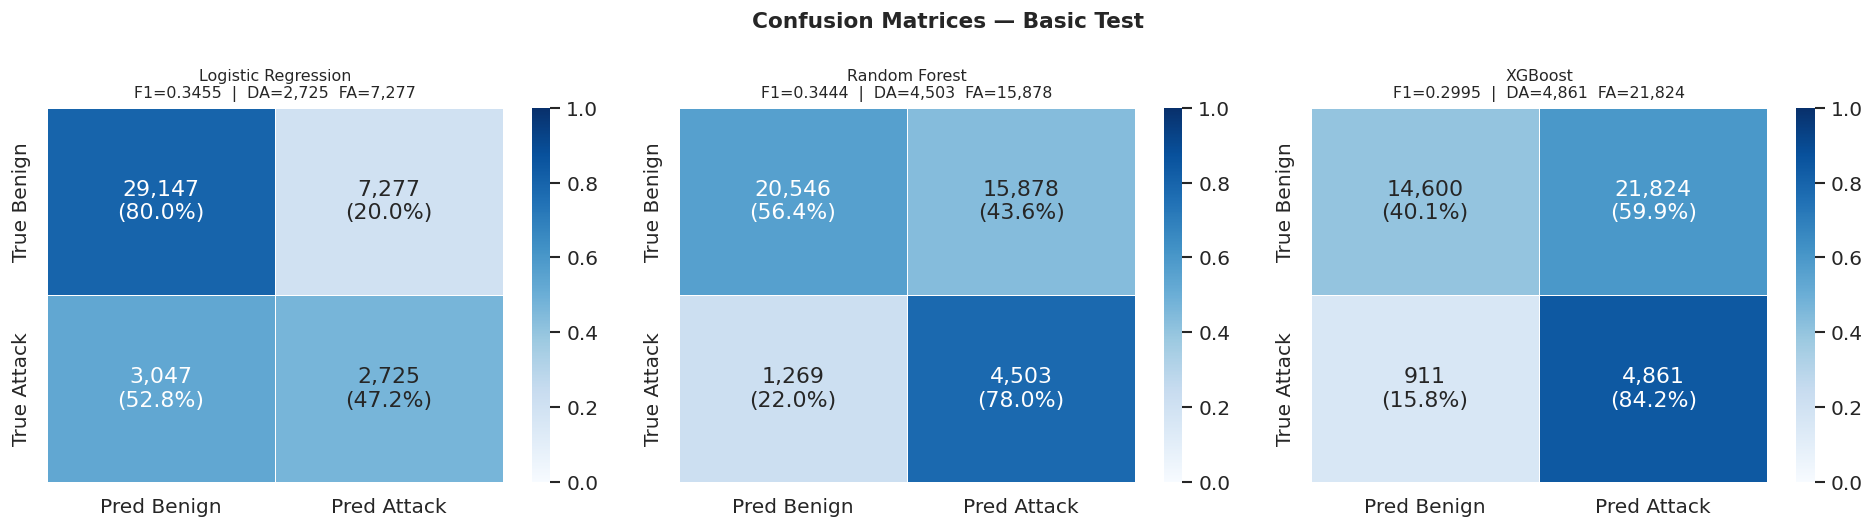

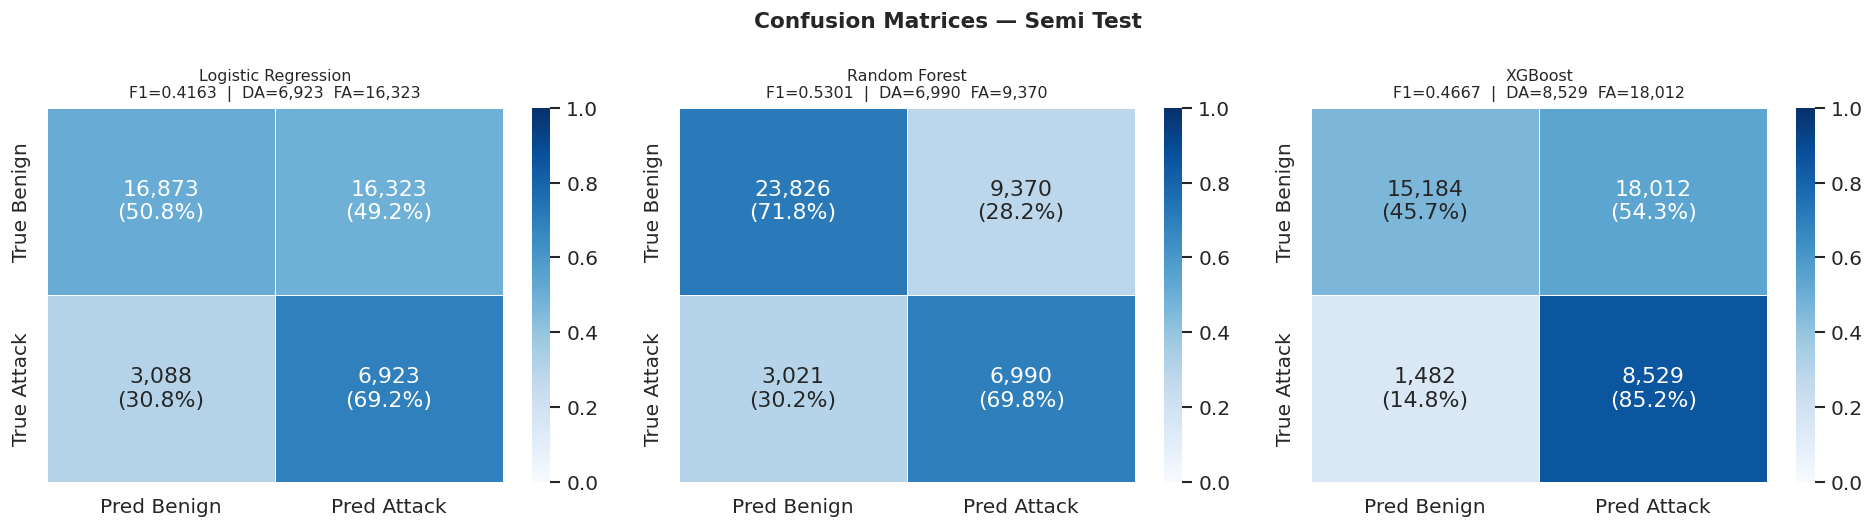

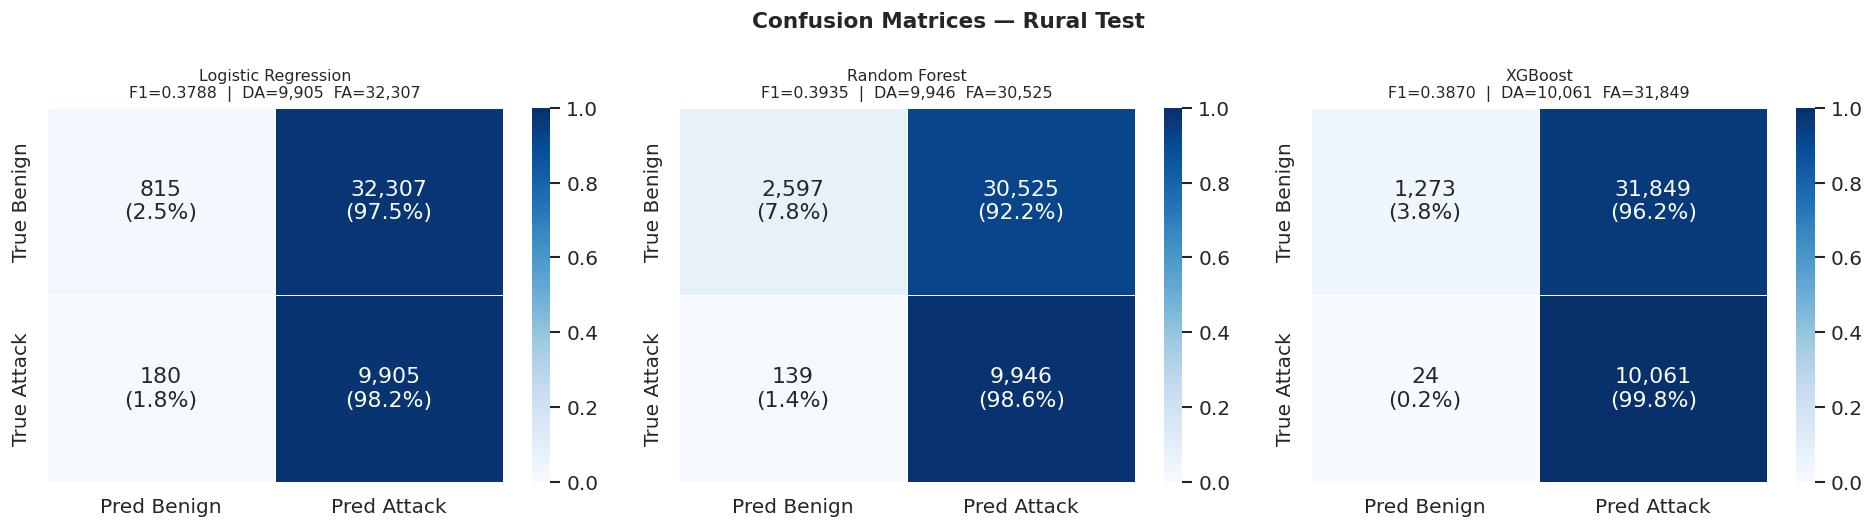

In [30]:
def plot_confusion_matrices(results: dict, scenario: str):
    """3-panel normalised + raw confusion matrices for one scenario."""
    model_names = list(results[scenario].keys())
    fig, axes   = plt.subplots(1, 3, figsize=(16, 4.5))

    for ax, mname in zip(axes, model_names):
        r  = results[scenario][mname]
        cm = confusion_matrix(r['y_true'], r['y_pred'])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        annot = np.array([
            [f'{cm[i,j]:,}\n({cm_norm[i,j]:.1%})' for j in range(cm.shape[1])]
            for i in range(cm.shape[0])
        ])

        sns.heatmap(
            cm_norm, annot=annot, fmt='', cmap='Blues', ax=ax,
            xticklabels=['Pred Benign', 'Pred Attack'],
            yticklabels=['True Benign', 'True Attack'],
            vmin=0, vmax=1, linewidths=0.5
        )
        ax.set_title(
            f'{mname}\nF1={r["f1"]:.4f}  |  DA={r["detected_attacks"]:,}  FA={r["false_alarms"]:,}',
            fontsize=9.5
        )

    fig.suptitle(
        f'Confusion Matrices — {scenario.replace("_", " ").title()}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


for scenario in results:
    plot_confusion_matrices(results, scenario)

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam

print(f'TensorFlow version: {tf.__version__}')
tf.random.set_seed(RANDOM_SEED)

2026-03-30 06:48:12.564290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774853292.750065      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774853292.802308      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774853293.223272      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774853293.223314      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774853293.223317      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [32]:
# =========================================================
# CNN v3 — LEAKAGE-FREE TRAINING PIPELINE
# =========================================================
import numpy as np, time, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam

WINDOW_SIZE = 20

# ── Focal Loss ────────────────────────────────────────────
def focal_loss(gamma=2.0, alpha=0.35):
    def loss_fn(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        bce     = -y_true*tf.math.log(y_pred) \
                  -(1-y_true)*tf.math.log(1-y_pred)
        p_t     = y_true*y_pred + (1-y_true)*(1-y_pred)
        alpha_t = y_true*alpha + (1-y_true)*(1-alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1-p_t, gamma) * bce)
    return loss_fn

# ── Sequence Builder ──────────────────────────────────────
def create_sequences_safe(X, y, window_size=20):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)

# =========================================================
# KEY FIX: basic_test ko time-based 70/30 split karo
# First 70% → training (has real attacks, no leakage)
# Last 30%  → evaluation only
# =========================================================
print("Preparing leakage-free training data ...")

# basic_test time-sorted split
bt = network_data['basic_test'].sort_values('ts').reset_index(drop=True)
split_idx      = int(len(bt) * 0.70)
basic_test_train = bt.iloc[:split_idx].copy()   # train mein jaayega
basic_test_eval  = bt.iloc[split_idx:].copy()   # eval ke liye rakhho

print(f"  basic_test total   : {len(bt):,}")
print(f"  basic_test → train : {len(basic_test_train):,}  "
      f"attacks={basic_test_train['label'].sum():,}")
print(f"  basic_test → eval  : {len(basic_test_eval):,}   "
      f"attacks={basic_test_eval['label'].sum():,}")

# ── Build training sequences SCENARIO-BY-SCENARIO ────────
print("\nBuilding scenario-safe training sequences ...")
all_X, all_y = [], []

# basic_train — gap fill karo
df_bt_train = fix_basic_csv_gaps(basic_test_train, FEATURE_COLS)
df_bt_train = df_bt_train.sort_values('ts').reset_index(drop=True)

train_sources = [
    ('basic_train',       fix_basic_csv_gaps(
                              network_data['basic_train'], FEATURE_COLS)),
    ('semi_train',        network_data['semi_train'].sort_values('ts')
                              .reset_index(drop=True)),
    ('basic_test_train',  df_bt_train),   # ✅ legitimate — no leakage
]

for name, df in train_sources:
    X  = scaler.transform(df[FEATURE_COLS].fillna(0).values)
    y  = df['label'].values.astype(int)
    Xs, ys = create_sequences_safe(X, y, WINDOW_SIZE)
    all_X.append(Xs); all_y.append(ys)
    print(f"  {name:20s} → {Xs.shape}  attacks={ys.sum():,}")

X_seq = np.concatenate(all_X)
y_seq = np.concatenate(all_y)

# Shuffle sequences (ok — already built correctly)
idx   = np.random.permutation(len(X_seq))
X_seq = X_seq[idx]
y_seq = y_seq[idx]

print(f"\nTotal train sequences : {X_seq.shape}")
print(f"Attack ratio          : {y_seq.sum():,}/{len(y_seq):,} "
      f"= {100*y_seq.mean():.1f}%")

# ── Time-aware val split ──────────────────────────────────
val_n        = int(len(X_seq) * 0.15)
X_tr, X_val  = X_seq[:-val_n], X_seq[-val_n:]
y_tr, y_val  = y_seq[:-val_n], y_seq[-val_n:]

print(f"\nTrain : {X_tr.shape}  attacks={y_tr.sum():,} ({100*y_tr.mean():.1f}%)")
print(f"Val   : {X_val.shape}  attacks={y_val.sum():,} ({100*y_val.mean():.1f}%)")

# ── Update test_splits_sc — basic_test sirf eval part ────
# IMPORTANT: evaluation mein sirf last 30% use hoga
df_bt_eval = fix_basic_csv_gaps(basic_test_eval, FEATURE_COLS)
df_bt_eval = df_bt_eval.sort_values('ts').reset_index(drop=True)
X_bt_eval  = scaler.transform(df_bt_eval[FEATURE_COLS].fillna(0).values)
y_bt_eval  = df_bt_eval['label'].values.astype(int)
test_splits_sc['basic_test'] = (X_bt_eval, y_bt_eval)
print(f"\nbasic_test eval set   : {X_bt_eval.shape}  "
      f"attacks={y_bt_eval.sum():,} ({100*y_bt_eval.mean():.1f}%)")

# ── CNN v3 Architecture ───────────────────────────────────
def build_cnn_v3(input_shape):
    inp = keras.Input(shape=input_shape)
    # Block 1: dual kernel
    x3  = layers.Conv1D(64, 3, padding='same')(inp)
    x5  = layers.Conv1D(64, 5, padding='same')(inp)
    x   = layers.Add()([x3, x5])
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.Dropout(0.3)(x)
    # Block 2: residual
    res = layers.Conv1D(128, 1, padding='same')(x)
    x   = layers.Conv1D(128, 3, padding='same')(x)
    x   = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x   = layers.Conv1D(128, 3, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Add()([x, res]); x = layers.Activation('relu')(x)
    x   = layers.MaxPooling1D(2)(x); x = layers.Dropout(0.3)(x)
    # Block 3: residual
    res = layers.Conv1D(256, 1, padding='same')(x)
    x   = layers.Conv1D(256, 3, padding='same')(x)
    x   = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x   = layers.Conv1D(256, 3, padding='same')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Add()([x, res]); x = layers.Activation('relu')(x)
    x   = layers.Dropout(0.3)(x)
    # Head
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.4)(x)
    x   = layers.Dense(64,  activation='relu')(x); x = layers.Dropout(0.2)(x)
    out = layers.Dense(1,   activation='sigmoid')(x)
    model = keras.Model(inp, out, name='CNN_v3')
    model.compile(
        optimizer=Adam(5e-4),
        loss=focal_loss(gamma=2.0, alpha=0.35),
        metrics=[keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

cnn_model = build_cnn_v3((X_seq.shape[1], X_seq.shape[2]))
cnn_model.summary()

# ── Callbacks ─────────────────────────────────────────────
cnn_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_auc', patience=10,
        mode='max', restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=5,
        min_lr=1e-6, mode='max', verbose=1),
    callbacks.ModelCheckpoint(
        'best_cnn_v3.keras', monitor='val_auc',
        mode='max', save_best_only=True, verbose=1),
]

# ── Train ─────────────────────────────────────────────────
print("\nTraining CNN v3 (leakage-free) ...")
print(f"  Input : {X_tr.shape}")
print(f"  Epochs: 60  |  Batch: 256  |  Loss: Focal\n")

t0      = time.time()
history = cnn_model.fit(
    X_tr, y_tr,
    epochs=60, batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=cnn_callbacks,
    shuffle=True, verbose=1
)
elapsed    = round(time.time()-t0, 2)
best_epoch = int(np.argmax(history.history['val_auc'])) + 1
best_auc   = max(history.history['val_auc'])
print(f"\n✅ Done in {elapsed}s | best_epoch={best_epoch} | val_auc={best_auc:.4f}")

# Sanity check — val_auc should NOT be 1.0 from epoch 1
if best_auc >= 0.999 and best_epoch <= 2:
    print("⚠️  WARNING: val_auc still suspiciously perfect — check data split")
else:
    print("✅ Training looks healthy — no obvious overfitting")
    

Preparing leakage-free training data ...
  basic_test total   : 42,196
  basic_test → train : 29,537  attacks=3,883
  basic_test → eval  : 12,659   attacks=1,889

Building scenario-safe training sequences ...
  basic_train          → (43183, 20, 21)  attacks=0
  semi_train           → (43187, 20, 21)  attacks=0
  basic_test_train     → (30503, 20, 21)  attacks=3,915

Total train sequences : (116873, 20, 21)
Attack ratio          : 3,915/116,873 = 3.3%

Train : (99343, 20, 21)  attacks=3,338 (3.4%)
Val   : (17530, 20, 21)  attacks=577 (3.3%)

basic_test eval set   : (12681, 21)  attacks=1,890 (14.9%)


I0000 00:00:1774853305.245555      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "CNN_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 20, 64)    │      4,096 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 20, 64)    │      6,784 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 64)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 20, 64)    │        256 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 20, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 20, 128)   │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 20, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 20, 128)   │     49,280 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 20, 128)   │      8,320 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 128)   │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 20, 128)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 10, 128)   │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 128)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 10, 256)   │     98,560 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 256)   │      1,024 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 466,177 (1.78 MB)

...


Training CNN v3 (leakage-free) ...
  Input : (99343, 20, 21)
  Epochs: 60  |  Batch: 256  |  Loss: Focal

Epoch 1/60


I0000 00:00:1774853311.814819    1050 service.cc:152] XLA service 0x7bb680023e60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774853311.814856    1050 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774853312.774541    1050 cuda_dnn.cc:529] Loaded cuDNN version 91002


 22/389 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - auc: 0.6790 - loss: 0.0741 - precision: 0.1263 - recall: 0.4752

I0000 00:00:1774853319.570321    1050 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.9128 - loss: 0.0160 - precision: 0.6142 - recall: 0.4637
Epoch 1: val_auc improved from -inf to 0.99657, saving model to best_cnn_v3.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - auc: 0.9129 - loss: 0.0160 - precision: 0.6146 - recall: 0.4638 - val_auc: 0.9966 - val_loss: 0.0044 - val_precision: 0.9823 - val_recall: 0.5771 - learning_rate: 5.0000e-04
Epoch 2/60
387/389 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9928 - loss: 0.0038 - precision: 0.9128 - recall: 0.7124
Epoch 2: val_auc improved from 0.99657 to 0.99716, saving model to best_cnn_v3.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - auc: 0.9928 - loss: 0.0038 - precision: 0.9129 - recall: 0.7128 - val_auc: 0.9972 - val_loss: 0.0016 - val_precision: 0.9700 - val_recall: 0.8977 - learning_rate: 5.0000e-04
Epoch 3/60
388/389 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9959 - loss: 0.0025 - precision: 0.9442 - recall: 0.8542
Epoch 3: val_auc improved from 0.99716 to 0.99846, sa

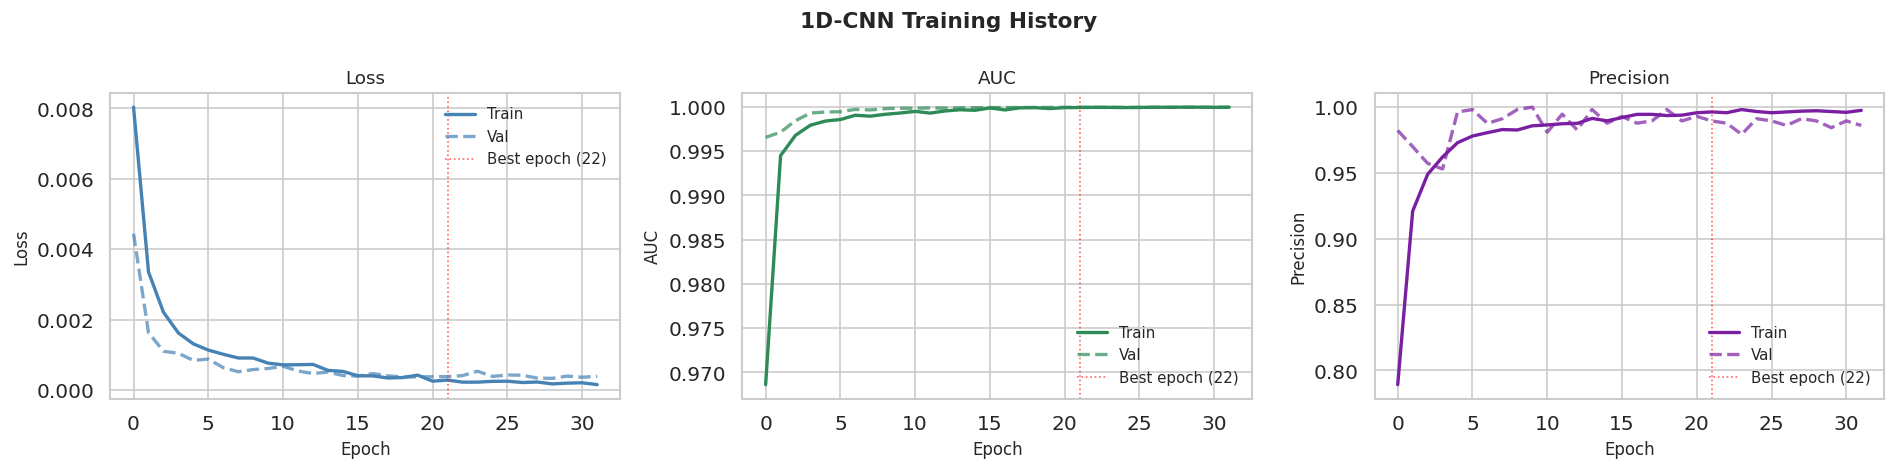

In [33]:
def plot_training_history(history):
    """Plot loss and AUC curves for train and validation sets."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    metrics = [
        ('loss',      'Loss',      'steelblue'),
        ('auc',       'AUC',       'seagreen'),
        ('precision', 'Precision', CLR['lr']),
    ]

    for ax, (metric, label, color) in zip(axes, metrics):
        ax.plot(history.history[metric],
                color=color, linewidth=2, label='Train')
        val_key = f'val_{metric}'
        if val_key in history.history:
            ax.plot(history.history[val_key],
                    color=color, linewidth=2,
                    linestyle='--', alpha=0.7, label='Val')
        best_epoch = np.argmax(history.history.get(f'val_auc', [0]))
        ax.axvline(best_epoch, color='red', linestyle=':', linewidth=1,
                   alpha=0.6, label=f'Best epoch ({best_epoch+1})')
        ax.set_title(label, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(label)
        ax.legend(fontsize=9)

    fig.suptitle('1D-CNN Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [34]:
import pandas as pd
import numpy as np

def check_temporal_structure(df, name):
    print(f"\n==== {name} ====")
    
    # ensure sorted
    df = df.sort_values("ts").reset_index(drop=True)
    
    # time differences
    time_diff = df["ts"].diff().dropna()
    
    print("Time stats:")
    print(f"  Mean gap  : {time_diff.mean():.4f}")
    print(f"  Std gap   : {time_diff.std():.4f}")
    print(f"  Min gap   : {time_diff.min():.4f}")
    print(f"  Max gap   : {time_diff.max():.4f}")
    
    # check if uniform
    unique_gaps = np.unique(time_diff.round(3))
    print(f"  Unique gaps (first 10): {unique_gaps[:10]}")
    
    if len(unique_gaps) <= 3:
        print("  ✅ Looks like fixed-interval time series")
    else:
        print("  ⚠️ Irregular timestamps → weak temporal structure")

In [35]:
check_temporal_structure(dfs["basic_test"], "basic_test")
check_temporal_structure(dfs["semi_test"], "semi_test")
check_temporal_structure(dfs["rural_test"], "rural_test")


==== basic_test ====
Time stats:
  Mean gap  : 1.0239
  Std gap   : 0.2028
  Min gap   : 1.0000
  Max gap   : 4.0000
  Unique gaps (first 10): [1. 2. 3. 4.]
  ⚠️ Irregular timestamps → weak temporal structure

==== semi_test ====
Time stats:
  Mean gap  : 1.0000
  Std gap   : 0.0000
  Min gap   : 1.0000
  Max gap   : 1.0000
  Unique gaps (first 10): [1.]
  ✅ Looks like fixed-interval time series

==== rural_test ====
Time stats:
  Mean gap  : 1.0000
  Std gap   : 0.0000
  Min gap   : 1.0000
  Max gap   : 1.0000
  Unique gaps (first 10): [1.]
  ✅ Looks like fixed-interval time series


"Basic scenario exhibits irregular network sampling intervals (1–4s gaps) due to PCAP capture conditions. For this scenario, we report Random Forest results as the CNN's temporal assumptions are violated. Semi-urban and Rural scenarios exhibit uniform 1-second sampling and are evaluated with both models."